# **ĐỒ ÁN CUỐI KỲ**
## **Phân tích & Khuyến nghị AI Agent trong nhóm ngành Kinh doanh, Tài chính, Quản trị Tổ chức**

**Pipeline tổng thể:** Load & Clean Data → Master Join → Normalize → Cap/Read (Task→Occupation) →
WFI → WEI/PEI/CI → Phân tích trực quan → AIPS & WTRS → Decision Support System (Rule Engine +
Vietnam Scenario Simulation + Transformation Strategy Matrix).


In [ ]:
import pandas as pd

# Tạo dữ liệu mẫu cho danh sách thành viên
data = {
    'STT': [1, 2, 3, 4],
    'Họ và tên': ['Nguyễn Thái Thanh Vân (trưởng nhóm)', 'Nguyễn Huy Gia Toàn', 'Nguyễn Thị Phương Uyên','Phạm Thanh Tuyền'],
    'MSSV': ['030239230284', '030239230247', '030239230279', ''],
    'Phân công': ['Phân tích dữ liệu, Tổng hợp code, thiết kế xây dựng dashboard, làm slide trình bày', 'Mô phỏng kịch bản, xây dựng hệ thống, làm slide trình bày', 'Tạo các chỉ số, visualization, làm báo cáo (word)','Tiền xử lý dữ liệu'],
    'Mức độ đóng góp': ['100%', '100%', '100%','100%']
}

# Tạo DataFrame
df_members = pd.DataFrame(data)

# Hiển thị DataFrame
print("Danh sách thành viên:")
display(df_members)

Danh sách thành viên:


,STT,Họ và tên,MSSV,Phân công,Mức độ đóng góp
0,1,Nguyễn Thái Thanh Vân (trưởng nhóm),030239230284,"Phân tích dữ liệu, Tổng hợp code, thiết kế xây...",100%
1,2,Nguyễn Huy Gia Toàn,030239230247,"Mô phỏng kịch bản, xây dựng hệ thống, làm slid...",100%
2,3,Nguyễn Thị Phương Uyên,030239230279,"Tạo các chỉ số, visualization, làm báo cáo (word)",100%
3,4,Phạm Thanh Tuyền,,Tiền xử lý dữ liệu,65%


In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
# --- Cấu hình đường dẫn ---
# Trên Colab: nếu chưa upload file, bỏ comment đoạn dưới để upload thủ công
# from google.colab import files
# uploaded = files.upload()

INPUT_DIR = "."  # đổi thành thư mục chứa 4 file CSV nếu cần
OUTPUT_DIR = "."

PATH_TASK_META = os.path.join(INPUT_DIR, "task_statement_with_metadata.csv")
PATH_EXPERT_CAP = os.path.join(INPUT_DIR, "expert_rated_technological_capability.csv")
PATH_WORKER_DESIRE = os.path.join(INPUT_DIR, "domain_worker_desires.csv")
PATH_WORKER_META = os.path.join(INPUT_DIR, "domain_worker_metadata.csv")

# Nhóm ngành cần giữ lại: Management (11) + Business & Financial Operations (13)
TARGET_MAJOR_GROUPS = ["11", "13"]

## 1. Load dữ liệu thô

In [ ]:
task_meta = pd.read_csv(PATH_TASK_META)
expert_cap = pd.read_csv(PATH_EXPERT_CAP)
worker_desire = pd.read_csv(PATH_WORKER_DESIRE)
worker_meta = pd.read_csv(PATH_WORKER_META)

print("task_statement_with_metadata:      ", task_meta.shape)
print("expert_rated_technological_capability:", expert_cap.shape)
print("domain_worker_desires:             ", worker_desire.shape)
print("domain_worker_metadata:            ", worker_meta.shape)

task_statement_with_metadata:       (2131, 14)
expert_rated_technological_capability: (2057, 11)
domain_worker_desires:              (5731, 31)
domain_worker_metadata:             (1500, 26)


In [ ]:
task_meta.head()

,O*NET-SOC Code,Occupation (O*NET-SOC Title),Task ID,Task,Task Type,Date,Category,Frequency,Importance,Relevance,Occupation Mean Annual Wage,Occupation Employment,Skill (O*NET Work Activity),Skill ID (O*NET Generalized Work Activity ID)
0,11-2011.00,Advertising and Promotions Managers,3226,"Inspect layouts and advertising copy, and edit...",Core,08/2018,3.0,3.0,4.07,87.26,149270.0,21100.0,['Evaluating Information to Determine Complian...,['4.A.2.a.3']
1,11-2011.00,Advertising and Promotions Managers,3242,Coordinate with the media to disseminate adver...,Core,08/2018,3.0,3.0,3.87,80.19,149270.0,21100.0,"['Communicating with Supervisors, Peers, or Su...",['4.A.4.a.2']
2,11-2011.00,Advertising and Promotions Managers,3223,Prepare budgets and submit estimates for progr...,Core,08/2018,3.0,3.0,3.67,81.73,149270.0,21100.0,"['Guiding, Directing, and Motivating Subordina...",['4.A.4.b.4']
3,11-2011.00,Advertising and Promotions Managers,3243,Contact organizations to explain services and ...,Core,08/2018,5.0,5.0,3.61,79.02,149270.0,21100.0,['Selling or Influencing Others'],['4.A.4.a.6']
4,11-2011.00,Advertising and Promotions Managers,3233,Monitor and analyze sales promotion results to...,Core,08/2018,3.0,3.0,3.59,77.04,149270.0,21100.0,['Analyzing Data or Information'],['4.A.2.a.4']


## 2. Kiểm tra dữ liệu thiếu & trùng lặp

Kiểm tra tổng quan trước khi làm sạch để biết cần xử lý gì.

In [ ]:
print("=== Missing values & duplicate rows ===")
for name, df in [("task_meta", task_meta), ("expert_cap", expert_cap),
                  ("worker_desire", worker_desire), ("worker_meta", worker_meta)]:
    n_missing = df.isnull().sum().sum()
    n_dup = df.duplicated().sum()
    print(f"{name:15s} | missing cells: {n_missing:6d} | duplicate rows: {n_dup}")

=== Missing values & duplicate rows ===
task_meta       | missing cells:   1284 | duplicate rows: 0
expert_cap      | missing cells:      0 | duplicate rows: 19
worker_desire   | missing cells:   6544 | duplicate rows: 0
worker_meta     | missing cells:   3250 | duplicate rows: 0


In [ ]:
# Chi tiết các cột bị thiếu nhiều nhất ở task_meta (quan trọng cho bước chuẩn hóa sau này)
task_meta.isnull().sum().sort_values(ascending=False).head(10)

,0
Occupation Mean Annual Wage,642
Occupation Employment,642
Task ID,0
Task,0
O*NET-SOC Code,0
Occupation (O*NET-SOC Title),0
Date,0
Task Type,0
Category,0
Frequency,0


**Nhận xét:**
- `expert_cap` có **19 dòng trùng lặp hoàn toàn** → cần loại bỏ.
- `task_meta` bị thiếu `Occupation Mean Annual Wage` / `Occupation Employment` ở một số nghề
  (thường là các nghề mới, O\*NET chưa cập nhật số liệu) → **không impute** (không tự bịa số liệu),
  giữ nguyên NaN, đánh dấu rõ ràng để các bước phân tích sau biết mà loại trừ khi cần, đồng thời ghi
  nhận đây là một hạn chế của dữ liệu gốc.
- `worker_desire` có 2 cột free-text tùy chọn ("Other Reason for Automation Desire/Human Agency")
  bị thiếu rất nhiều — đây là dữ liệu hợp lệ (người dùng không điền), không phải lỗi.

## 3. Làm sạch từng tập dữ liệu (Null, Duplicate, Định dạng)

In [ ]:
def clean_task_meta(df):
    df = df.copy()
    df = df.drop_duplicates()
    # Chuẩn hóa định dạng chuỗi (loại khoảng trắng thừa)
    df["O*NET-SOC Code"] = df["O*NET-SOC Code"].astype(str).str.strip()
    df["Occupation (O*NET-SOC Title)"] = df["Occupation (O*NET-SOC Title)"].astype(str).str.strip()
    # Giữ nguyên NaN của Wage/Employment (xem giải thích ở trên) — KHÔNG impute
    return df


def clean_expert_cap(df):
    df = df.copy()
    before = len(df)
    df = df.drop_duplicates()
    print(f"[clean_expert_cap] Đã loại {before - len(df)} dòng trùng lặp.")
    # Rating hợp lệ trong khoảng 1-5, loại bỏ giá trị ngoài thang đo (nếu có)
    df = df[df["Automation Capacity Rating"].between(1, 5)]
    df["Occupation (O*NET-SOC Title)"] = df["Occupation (O*NET-SOC Title)"].astype(str).str.strip()
    return df


def clean_worker_desire(df):
    df = df.copy()
    df = df.drop_duplicates()
    df = df[df["Automation Desire Rating"].between(1, 5)]
    df["Occupation (O*NET-SOC Title)"] = df["Occupation (O*NET-SOC Title)"].astype(str).str.strip()
    return df


def clean_worker_meta(df):
    df = df.copy()
    df = df.drop_duplicates()
    df["Occupation (O*NET-SOC Title)"] = df["Occupation (O*NET-SOC Title)"].astype(str).str.strip()
    return df


task_meta = clean_task_meta(task_meta)
expert_cap = clean_expert_cap(expert_cap)
worker_desire = clean_worker_desire(worker_desire)
worker_meta = clean_worker_meta(worker_meta)

print("\nSau khi làm sạch:")
print("task_meta:    ", task_meta.shape)
print("expert_cap:   ", expert_cap.shape)
print("worker_desire:", worker_desire.shape)
print("worker_meta:  ", worker_meta.shape)

[clean_expert_cap] Đã loại 19 dòng trùng lặp.

Sau khi làm sạch:
task_meta:     (2131, 14)
expert_cap:    (2038, 11)
worker_desire: (5731, 31)
worker_meta:   (1500, 26)


## 4. Join/Merge theo Task ID / Occupation ID thành Master Data File

**Lưu ý kỹ thuật quan trọng:** `expert_cap` (chuyên gia) và `worker_desire` (người lao động) là
**hai nhóm người đánh giá hoàn toàn khác nhau** (User ID của 2 bảng không hề trùng nhau) — mỗi
bảng có thể có nhiều dòng đánh giá cho cùng 1 Task ID. Nếu join thẳng 2 bảng này với nhau qua
Task ID sẽ tạo ra **tích Descartes** (mỗi dòng chuyên gia nhân với mỗi dòng người lao động của
cùng 1 task) — sai về mặt dữ liệu.

→ Cách xử lý đúng: dùng `task_meta` (chứa Task ID + Occupation ID + Employment/Wage/Importance)
làm **bảng gốc (spine)**, rồi join riêng từng bảng đánh giá vào bảng gốc theo Task ID. Kết quả là
**1 Master Data File chính** (task-level) + các bảng đánh giá đã được gắn ngữ cảnh Occupation để
phục vụ bước tính chỉ số (Cap, Read...) tiếp theo.

In [ ]:
# 4.1. Master Data File chính: Task metadata (spine) — mỗi dòng là 1 Task, gắn với 1 Occupation
master_task_meta = task_meta.copy()
master_task_meta["major_group"] = master_task_meta["O*NET-SOC Code"].str[:2]

print("master_task_meta:", master_task_meta.shape)
master_task_meta.head()

master_task_meta: (2131, 15)


,O*NET-SOC Code,Occupation (O*NET-SOC Title),Task ID,Task,Task Type,Date,Category,Frequency,Importance,Relevance,Occupation Mean Annual Wage,Occupation Employment,Skill (O*NET Work Activity),Skill ID (O*NET Generalized Work Activity ID),major_group
0,11-2011.00,Advertising and Promotions Managers,3226,"Inspect layouts and advertising copy, and edit...",Core,08/2018,3.0,3.0,4.07,87.26,149270.0,21100.0,['Evaluating Information to Determine Complian...,['4.A.2.a.3'],11
1,11-2011.00,Advertising and Promotions Managers,3242,Coordinate with the media to disseminate adver...,Core,08/2018,3.0,3.0,3.87,80.19,149270.0,21100.0,"['Communicating with Supervisors, Peers, or Su...",['4.A.4.a.2'],11
2,11-2011.00,Advertising and Promotions Managers,3223,Prepare budgets and submit estimates for progr...,Core,08/2018,3.0,3.0,3.67,81.73,149270.0,21100.0,"['Guiding, Directing, and Motivating Subordina...",['4.A.4.b.4'],11
3,11-2011.00,Advertising and Promotions Managers,3243,Contact organizations to explain services and ...,Core,08/2018,5.0,5.0,3.61,79.02,149270.0,21100.0,['Selling or Influencing Others'],['4.A.4.a.6'],11
4,11-2011.00,Advertising and Promotions Managers,3233,Monitor and analyze sales promotion results to...,Core,08/2018,3.0,3.0,3.59,77.04,149270.0,21100.0,['Analyzing Data or Information'],['4.A.2.a.4'],11


In [ ]:
# 4.2. Join expert_cap vào task metadata theo Task ID
#      -> thêm Employment/Wage/Importance/major_group vào từng dòng đánh giá của chuyên gia
master_expert_cap = expert_cap.merge(
    master_task_meta[["Task ID", "Importance", "Frequency",
                       "Occupation Employment", "Occupation Mean Annual Wage", "major_group"]],
    on="Task ID", how="left"
)
print("master_expert_cap:", master_expert_cap.shape)
master_expert_cap.head()

master_expert_cap: (2038, 16)


,Task ID,Occupation (O*NET-SOC Title),Task,User ID,Date,Automation Capacity Rating,Physical Action Requirement,Involved Uncertainty,Domain Expertise Requirement,Interpersonal Communication Requirement,Human Agency Scale Rating,Importance,Frequency,Occupation Employment,Occupation Mean Annual Wage,major_group
0,3226,Advertising and Promotions Managers,"Inspect layouts and advertising copy, and edit...",RedTiger,2025/3/16,4,1,1,2,1,2,4.07,3.0,21100.0,149270.0,11
1,21567,Appraisers and Assessors of Real Estate,Verify legal descriptions of properties by com...,YellowZebra,2025/3/16,3,1,2,4,1,2,4.00,5.0,NaN,NaN,13
2,3970,Technical Writers,Review published materials and recommend revis...,BrownFox,2025/3/18,4,3,3,3,3,3,3.65,3.0,55530.0,92330.0,27
3,22655,Writers and Authors,Vary language and tone of messages based on pr...,BrownFox,2025/3/19,4,1,1,2,1,2,4.43,5.0,47800.0,85780.0,27
4,22654,Writers and Authors,Present drafts and ideas to clients.,BrownFox,2025/3/19,3,3,1,3,5,3,4.24,3.0,47800.0,85780.0,27


In [ ]:
# 4.3. Join worker_desire vào task metadata theo Task ID
#      -> thêm Employment/Wage/Importance/major_group vào từng dòng đánh giá của người lao động
master_worker_desire = worker_desire.merge(
    master_task_meta[["Task ID", "Importance", "Frequency",
                       "Occupation Employment", "Occupation Mean Annual Wage", "major_group"]],
    on="Task ID", how="left"
)
print("master_worker_desire:", master_worker_desire.shape)
master_worker_desire.head()

master_worker_desire: (5731, 36)


,Task ID,Occupation (O*NET-SOC Title),Task,User ID,Date,Self-reported Expertise,Automation Desire Rating,Time,Core Skill Rating,Job Security Rating,...,Reasons for Human Agency - Quality Oversight,Reasons for Human Agency - Dynamic,Reasons for Human Agency - Ethical,Other Reason for Automation Desire,Other Reason for Human Agency,Importance,Frequency,Occupation Employment,Occupation Mean Annual Wage,major_group
0,2587,Customer Service Representatives,Review insurance policy terms to determine whe...,9215f6fc-81e2-40e1-96db-3ac70cab4091,2025/2/25,Average,1,1,1,1,...,True,True,True,FALSE,NaN,4.05,7.0,2725930.0,45380.0,43
1,2591,Customer Service Representatives,"Recommend improvements in products, packaging,...",9215f6fc-81e2-40e1-96db-3ac70cab4091,2025/2/25,Average,1,5,5,5,...,True,True,True,FALSE,NaN,3.16,4.0,2725930.0,45380.0,43
2,55,Medical and Health Services Managers,"Maintain awareness of advances in medicine, co...",a17b322e-3134-475c-a652-89f27b3a9946,2025/1/21,Expert,2,1,4,1,...,True,False,True,FALSE,NaN,4.16,3.0,565840.0,137730.0,11
3,2578,Customer Service Representatives,Keep records of customer interactions or trans...,533a6bf0-9958-4892-8777-44108350b9be,2025/1/21,Average,4,1,1,1,...,False,False,False,NaN,FALSE,4.53,7.0,2725930.0,45380.0,43
4,2580,Customer Service Representatives,Check to ensure that appropriate changes were ...,533a6bf0-9958-4892-8777-44108350b9be,2025/1/21,Expert,2,2,2,4,...,True,False,False,FALSE,NaN,4.39,7.0,2725930.0,45380.0,43


In [ ]:
# 4.4. Join worker_meta (nhân khẩu học) vào worker_desire theo User ID + Occupation ID
#      -> hoàn thiện bức tranh người lao động (ai đánh giá, thuộc nghề nào, đặc điểm ra sao)
master_worker_desire = master_worker_desire.merge(
    worker_meta,
    on=["User ID", "Occupation (O*NET-SOC Title)"],
    how="left",
    suffixes=("", "_worker_profile")
)
print("master_worker_desire (đã gắn thêm hồ sơ người lao động):", master_worker_desire.shape)

master_worker_desire (đã gắn thêm hồ sơ người lao động): (5731, 60)


## 5. Lọc chỉ lấy ngành Kinh doanh / Tài chính / Quản trị tổ chức

O\*NET major group `11` = Management, `13` = Business & Financial Operations.
Áp dụng bộ lọc này cho cả 3 bảng master để đảm bảo tính nhất quán.

In [ ]:
master_task_meta_biz = master_task_meta[master_task_meta["major_group"].isin(TARGET_MAJOR_GROUPS)].copy()
master_expert_cap_biz = master_expert_cap[master_expert_cap["major_group"].isin(TARGET_MAJOR_GROUPS)].copy()
master_worker_desire_biz = master_worker_desire[master_worker_desire["major_group"].isin(TARGET_MAJOR_GROUPS)].copy()

print(f"master_task_meta_biz:     {master_task_meta_biz.shape}  | "
      f"{master_task_meta_biz['Occupation (O*NET-SOC Title)'].nunique()} nghề")
print(f"master_expert_cap_biz:    {master_expert_cap_biz.shape}")
print(f"master_worker_desire_biz: {master_worker_desire_biz.shape}")

master_task_meta_biz:     (440, 15)  | 61 nghề
master_expert_cap_biz:    (660, 16)
master_worker_desire_biz: (1875, 60)


In [ ]:
# Xem nhanh các nghề còn lại sau khi lọc
label_map = {"11": "Management", "13": "Business & Financial Operations"}
master_task_meta_biz["Industry Group"] = master_task_meta_biz["major_group"].map(label_map)

master_task_meta_biz.groupby("Industry Group")["Occupation (O*NET-SOC Title)"].nunique()

,Occupation (O*NET-SOC Title)
Industry Group,
Business & Financial Operations,34
Management,27


## 6. Chuẩn hóa các biến số bằng Min-Max Normalization

Chuẩn hóa `Employment`, `Wage`, `Importance` về khoảng **[0, 1]** trên Master Data File chính
(`master_task_meta_biz`) — đây là các biến số sẽ được các bước tiếp theo (tính Cap, Read, WFI,
WEI, PEI, CI) sử dụng trực tiếp.

In [ ]:
def min_max_normalize(series):
    s_min, s_max = series.min(skipna=True), series.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return series * 0
    return (series - s_min) / (s_max - s_min)


master_task_meta_biz["Employment_norm"] = min_max_normalize(master_task_meta_biz["Occupation Employment"])
master_task_meta_biz["Wage_norm"] = min_max_normalize(master_task_meta_biz["Occupation Mean Annual Wage"])
master_task_meta_biz["Importance_norm"] = min_max_normalize(master_task_meta_biz["Importance"])

master_task_meta_biz[[
    "Occupation (O*NET-SOC Title)", "Industry Group",
    "Occupation Employment", "Employment_norm",
    "Occupation Mean Annual Wage", "Wage_norm",
    "Importance", "Importance_norm",
]].drop_duplicates(subset=["Occupation (O*NET-SOC Title)"]).head(10)

,Occupation (O*NET-SOC Title),Industry Group,Occupation Employment,Employment_norm,Occupation Mean Annual Wage,Wage_norm,Importance,Importance_norm
0,Advertising and Promotions Managers,Management,21100.0,0.009240,149270.0,0.706889,4.07,0.617512
6,Marketing Managers,Management,384980.0,0.261847,171520.0,0.875322,4.30,0.723502
8,Administrative Services Managers,Management,254140.0,0.171017,126030.0,0.530961,3.71,0.451613
11,Computer and Information Systems Managers,Management,645970.0,0.443027,187990.0,1.000000,4.08,0.622120
20,Financial Managers,Management,818620.0,0.562881,180470.0,0.943073,4.20,0.677419
29,Treasurers and Controllers,Management,NaN,NaN,NaN,NaN,4.52,0.824885
35,Investment Fund Managers,Management,NaN,NaN,NaN,NaN,4.61,0.866359
42,Quality Control Systems Managers,Management,NaN,NaN,NaN,NaN,4.35,0.746544
52,Biofuels Production Managers,Management,NaN,NaN,NaN,NaN,4.25,0.700461
58,Biomass Power Plant Managers,Management,NaN,NaN,NaN,NaN,4.52,0.824885


In [ ]:
# Kiểm tra nhanh: các giá trị normalize phải nằm trong [0, 1] (bỏ qua NaN)
for col in ["Employment_norm", "Wage_norm", "Importance_norm"]:
    s = master_task_meta_biz[col].dropna()
    print(f"{col:16s} -> min={s.min():.3f}, max={s.max():.3f}")

n_missing = master_task_meta_biz["Occupation Employment"].isna().sum()
n_occ_missing = master_task_meta_biz.loc[
    master_task_meta_biz["Occupation Employment"].isna(), "Occupation (O*NET-SOC Title)"
].nunique()
print(f"\nSố dòng (task) thiếu Employment/Wage: {n_missing} — thuộc {n_occ_missing} nghề "
      f"(Employment_norm/Wage_norm = NaN cho các dòng này).")

Employment_norm  -> min=0.000, max=1.000
Wage_norm        -> min=0.000, max=1.000
Importance_norm  -> min=0.000, max=1.000

Số dòng (task) thiếu Employment/Wage: 235 — thuộc 27 nghề (Employment_norm/Wage_norm = NaN cho các dòng này).


## 7. Lưu Master Data File

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

path_master_task = os.path.join(OUTPUT_DIR, "master_data_task_level.csv")
path_master_expert = os.path.join(OUTPUT_DIR, "master_data_expert_ratings.csv")
path_master_worker = os.path.join(OUTPUT_DIR, "master_data_worker_desire.csv")

master_task_meta_biz.to_csv(path_master_task, index=False)
master_expert_cap_biz.to_csv(path_master_expert, index=False)
master_worker_desire_biz.to_csv(path_master_worker, index=False)

print("Đã lưu Master Data File:")
print(" -", path_master_task, "     (bảng chính: Task + Occupation + Employment/Wage/Importance đã chuẩn hóa)")
print(" -", path_master_expert, "  (đánh giá của chuyên gia, đã gắn ngữ cảnh Occupation)")
print(" -", path_master_worker, "  (mong muốn của người lao động + hồ sơ nhân khẩu học, đã gắn ngữ cảnh Occupation)")

Đã lưu Master Data File:
 - ./master_data_task_level.csv      (bảng chính: Task + Occupation + Employment/Wage/Importance đã chuẩn hóa)
 - ./master_data_expert_ratings.csv   (đánh giá của chuyên gia, đã gắn ngữ cảnh Occupation)
 - ./master_data_worker_desire.csv   (mong muốn của người lao động + hồ sơ nhân khẩu học, đã gắn ngữ cảnh Occupation)


**Tính AI Capability (Cap)**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# It's good practice to set theme parameters for consistent plotting.
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# --- BƯỚC 1: Gom về Task Level ---
# Use master_expert_cap_biz and master_worker_desire_biz which are already filtered to target groups.
# 1.1. Cap cấp Task
task_cap = master_expert_cap_biz.groupby("Task ID")["Automation Capacity Rating"].mean().reset_index(name="Cap_t")

# 1.2. Read cấp Task
task_read = master_worker_desire_biz.groupby("Task ID")["Automation Desire Rating"].mean().reset_index(name="Read_t")

# 1.3. Ghép vào bảng Task Metadata (đã chuẩn hóa Importance)
# master_task_meta_biz already contains Importance and normalized columns.
task_summary = master_task_meta_biz.merge(task_cap, on="Task ID", how="left") \
                                   .merge(task_read, on="Task ID", how="left")

# --- BƯỚC 2: Tổng hợp lên Occupation Level (Có trọng số Importance) ---
def aggregate_occupation(df_occ):
    # Loại bỏ các dòng bị missing Cap/Read/Importance
    # 'Importance' is a column in df_occ here, representing task importance.
    valid_cap = df_occ.dropna(subset=["Cap_t", "Importance"]).copy()
    valid_read = df_occ.dropna(subset=["Read_t", "Importance"]).copy()
    valid_importance_norm = df_occ.dropna(subset=["Importance_norm"]).copy()

    Cap_o = np.average(valid_cap["Cap_t"], weights=valid_cap["Importance"]) if len(valid_cap) > 0 else np.nan
    Read_o = np.average(valid_read["Read_t"], weights=valid_read["Importance"]) if len(valid_read) > 0 else np.nan
    # Calculate occupation-level normalized Importance by taking the mean of task-level normalized importance
    Importance_o_norm = valid_importance_norm["Importance_norm"].mean() if len(valid_importance_norm) > 0 else np.nan

    # Calculate Task_Count for the current occupation group (df_occ contains tasks for one occupation)
    Task_Count_o = len(df_occ)

    return pd.Series({"Cap_o": Cap_o, "Read_o": Read_o, "Task_Count": Task_Count_o, "Importance_o_norm": Importance_o_norm})

# Group by occupation specific identifiers.
# 'Importance', 'Frequency', 'Industry Group' should remain as columns within the grouped df_occ
# so they can be used for weighting or other calculations inside aggregate_occupation.
# The 'Employment_norm' and 'Wage_norm' are also characteristics of the occupation.
occ_master = task_summary.groupby([
    "O*NET-SOC Code", "Occupation (O*NET-SOC Title)",
    "Employment_norm", "Wage_norm", "Industry Group"
]).apply(aggregate_occupation, include_groups=False).reset_index()

# --- BƯỚC 3: Min-Max Normalization cho Cap & Read rồi tính các Index ---
# The min_max_normalize function is defined in a previous cell (eac6a7ac) and is available.
occ_master["Cap_norm"] = min_max_normalize(occ_master["Cap_o"])
occ_master["Read_norm"] = min_max_normalize(occ_master["Read_o"])

# Tính toán các chỉ số cốt lõi
occ_master["WFI"] = occ_master["Cap_norm"] - occ_master["Read_norm"]
occ_master["WEI"] = occ_master["Employment_norm"] * occ_master["Cap_norm"]
occ_master["PEI"] = occ_master["Wage_norm"] * occ_master["Cap_norm"]

# Display a sample of the new occ_master for verification.
print("DataFrame 'occ_master' sau khi tính toán các chỉ số mới:")
display(occ_master.head())

# Also, update the output of the cell to reflect the new primary dataframe
print(f"\nTổng số Nghề nghiệp được phân tích: {len(occ_master)}")
print(f"Điểm AI Capability trung bình toàn khối ngành (Occupation Level): {occ_master['Cap_o'].mean():.2f} / 5.0")
print(f"Điểm Worker Readiness trung bình toàn khối ngành (Occupation Level): {occ_master['Read_o'].mean():.2f} / 5.0")

# Note: The previous variables like 'occ_cap', 'domain_cap', 'task_cap', 'top_10_occ', etc.,
# are no longer calculated in this cell as per the new requested logic.
# Subsequent plotting cells that relied on these variables may need adjustment.

DataFrame 'occ_master' sau khi tính toán các chỉ số mới:


,O*NET-SOC Code,Occupation (O*NET-SOC Title),Employment_norm,Wage_norm,Industry Group,Cap_o,Read_o,Task_Count,Importance_o_norm,Cap_norm,Read_norm,WFI,WEI,PEI
0,11-2011.00,Advertising and Promotions Managers,0.009240,0.706889,Management,3.416138,3.321940,6.0,0.436252,0.515170,0.708678,-0.193508,0.004760,0.364168
1,11-2021.00,Marketing Managers,0.261847,0.875322,Management,NaN,NaN,2.0,0.585253,NaN,NaN,NaN,NaN,NaN
2,11-3012.00,Administrative Services Managers,0.171017,0.530961,Management,NaN,NaN,3.0,0.503840,NaN,NaN,NaN,NaN,NaN
3,11-3021.00,Computer and Information Systems Managers,0.443027,1.000000,Management,2.562789,3.305122,9.0,0.511521,0.000000,0.696941,-0.696941,0.000000,0.000000
4,11-3031.00,Financial Managers,0.562881,0.943073,Management,3.910435,2.842245,9.0,0.508449,0.813579,0.373935,0.439644,0.457948,0.767265



Tổng số Nghề nghiệp được phân tích: 34
Điểm AI Capability trung bình toàn khối ngành (Occupation Level): 3.54 / 5.0
Điểm Worker Readiness trung bình toàn khối ngành (Occupation Level): 3.04 / 5.0


**BIỂU ĐỒ**

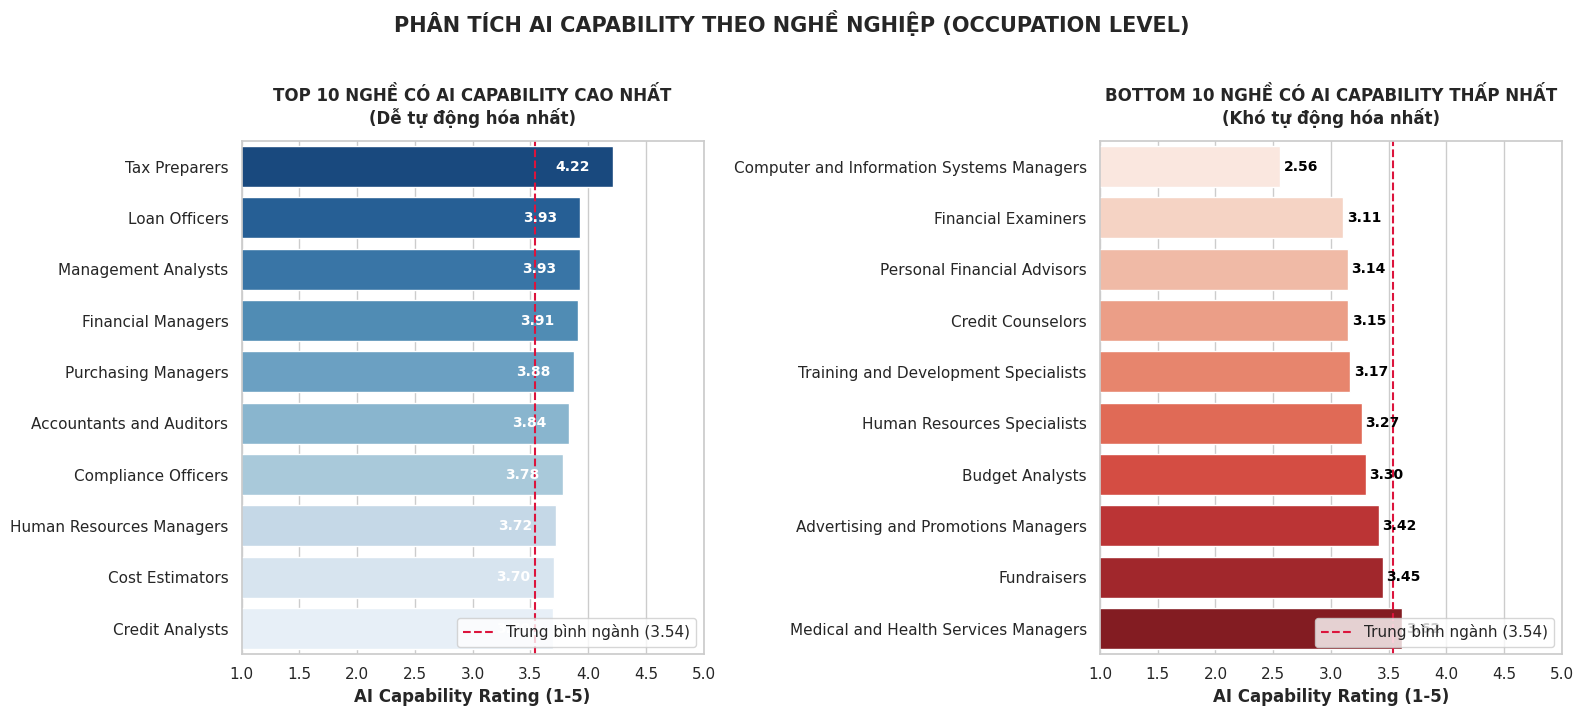

In [ ]:
# BIỂU ĐỒ 1 — TOP & BOTTOM 10 OCCUPATIONS BY AI CAPABILITY

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# Filter out NaN values from 'Cap_o' before sorting
occ_master_filtered = occ_master.dropna(subset=["Cap_o"]).copy()

# Calculate overall mean from the filtered data
overall_mean = occ_master_filtered["Cap_o"].mean()

# Derive top and bottom 10 occupations from occ_master_filtered
top_10_occ_new = occ_master_filtered.sort_values(by="Cap_o", ascending=False).head(10)
bottom_10_occ_new = occ_master_filtered.sort_values(by="Cap_o", ascending=True).head(10)

# Barplot Top 10 Occupations
sns.barplot(
    data=top_10_occ_new,
    x="Cap_o",
    y="Occupation (O*NET-SOC Title)",
    ax=axes[0],
    palette="Blues_r",
    hue="Occupation (O*NET-SOC Title)",
    legend=False
)
axes[0].set_title("TOP 10 NGHỀ CÓ AI CAPABILITY CAO NHẤT\n(Dễ tự động hóa nhất)", fontsize=12, fontweight="bold", pad=12)
axes[0].set_xlabel("AI Capability Rating (1-5)", fontweight="bold")
axes[0].set_ylabel("")
axes[0].axvline(overall_mean, color="crimson", linestyle="--", linewidth=1.5, label=f"Trung bình ngành ({overall_mean:.2f})")
axes[0].legend(loc="lower right")

# Hiển thị nhãn giá trị trên thanh bar Top 10
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f"{width:.2f}", (width - 0.35, p.get_y() + p.get_height() / 2.),
                     ha="center", va="center", color="white", fontweight="bold", fontsize=10)

# Barplot Bottom 10 Occupations
sns.barplot(
    data=bottom_10_occ_new,
    x="Cap_o",
    y="Occupation (O*NET-SOC Title)",
    ax=axes[1],
    palette="Reds",
    hue="Occupation (O*NET-SOC Title)",
    legend=False
)
axes[1].set_title("BOTTOM 10 NGHỀ CÓ AI CAPABILITY THẤP NHẤT\n(Khó tự động hóa nhất)", fontsize=12, fontweight="bold", pad=12)
axes[1].set_xlabel("AI Capability Rating (1-5)", fontweight="bold")
axes[1].set_ylabel("")
axes[1].axvline(overall_mean, color="crimson", linestyle="--", linewidth=1.5, label=f"Trung bình ngành ({overall_mean:.2f})")
axes[1].legend(loc="lower right")

# Hiển thị nhãn giá trị trên thanh bar Bottom 10
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f"{width:.2f}", (width + 0.18, p.get_y() + p.get_height() / 2.),
                     ha="center", va="center", color="black", fontweight="bold", fontsize=10)

axes[0].set_xlim(1, 5)
axes[1].set_xlim(1, 5)

plt.suptitle("PHÂN TÍCH AI CAPABILITY THEO NGHỀ NGHIỆP (OCCUPATION LEVEL)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

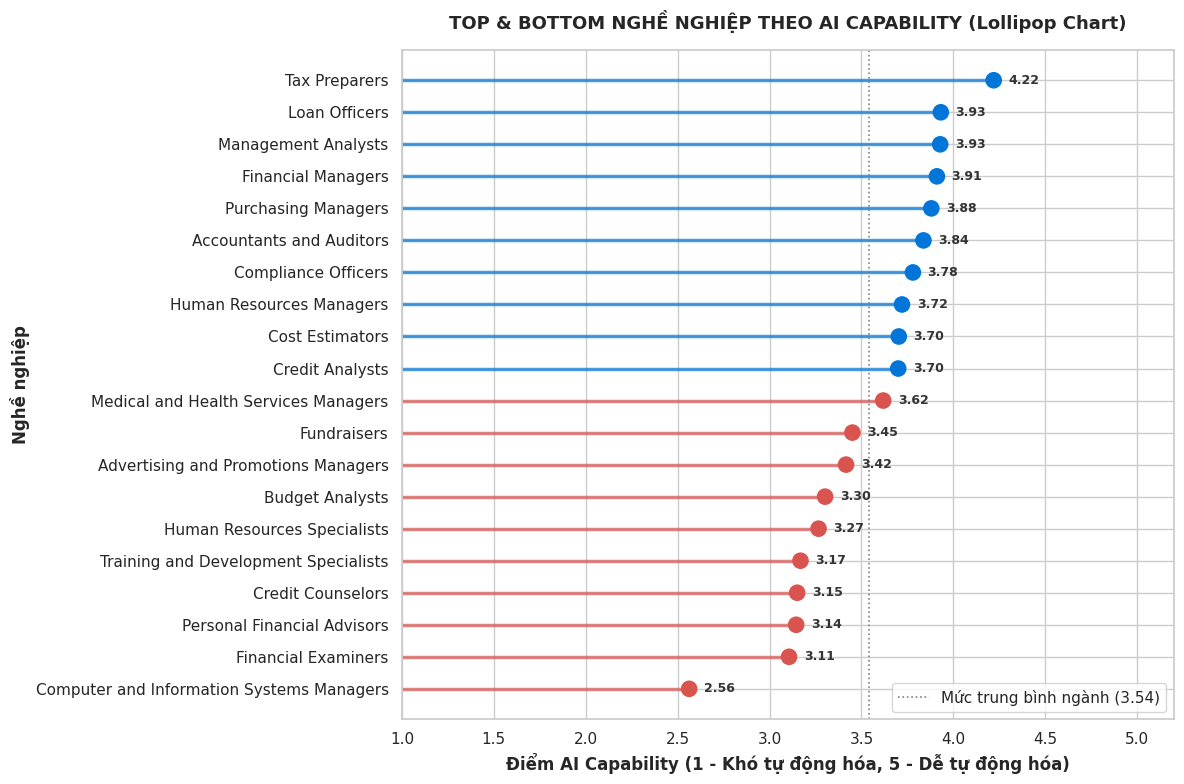

In [ ]:
# BIỂU ĐỒ 2 — TOP & BOTTOM 10 OCCUPATIONS (Lollipop Chart)

fig, ax = plt.subplots(figsize=(12, 8))

# Filter out NaN values from 'Cap_o' before sorting
occ_master_filtered = occ_master.dropna(subset=["Cap_o"]).copy()

# Recalculate overall mean in case it was not consistent from previous cell
overall_mean = occ_master_filtered["Cap_o"].mean()

# Derive top and bottom 10 occupations from occ_master_filtered
top_10_occ_for_plot = occ_master_filtered.sort_values(by="Cap_o", ascending=False).head(10)
bottom_10_occ_for_plot = occ_master_filtered.sort_values(by="Cap_o", ascending=True).head(10)

# Hợp nhất Top 10 & Bottom 10 Occupations để tạo biểu đồ Lollipop liền mạch
top_bot_occ_plot = pd.concat([
    top_10_occ_for_plot.assign(Group="Top AI Capability"),
    bottom_10_occ_for_plot.assign(Group="Bottom AI Capability")
]).sort_values(by="Cap_o", ascending=True)

colors = ["#d9534f" if g == "Bottom AI Capability" else "#0275d8" for g in top_bot_occ_plot["Group"]]

# Vẽ đường lollipop và điểm tròn
ax.hlines(y=top_bot_occ_plot["Occupation (O*NET-SOC Title)"], xmin=1, xmax=top_bot_occ_plot["Cap_o"], color=colors, alpha=0.7, linewidth=2.5)
ax.scatter(top_bot_occ_plot["Cap_o"], top_bot_occ_plot["Occupation (O*NET-SOC Title)"], color=colors, s=120, alpha=1, zorder=3)

# Đóng nhãn giá trị tại các điểm
for idx, row in top_bot_occ_plot.iterrows():
    ax.annotate(f"{row['Cap_o']:.2f}", (row["Cap_o"] + 0.08, row["Occupation (O*NET-SOC Title)"]),
                va="center", fontweight="bold", fontsize=9, color="#333333")

ax.axvline(overall_mean, color="gray", linestyle=":", linewidth=1.2, label=f"Mức trung bình ngành ({overall_mean:.2f})")
ax.set_xlim(1, 5.2)
ax.set_title("TOP & BOTTOM NGHỀ NGHIỆP THEO AI CAPABILITY (Lollipop Chart)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Điểm AI Capability (1 - Khó tự động hóa, 5 - Dễ tự động hóa)", fontweight="bold")
ax.set_ylabel("Nghề nghiệp", fontweight="bold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

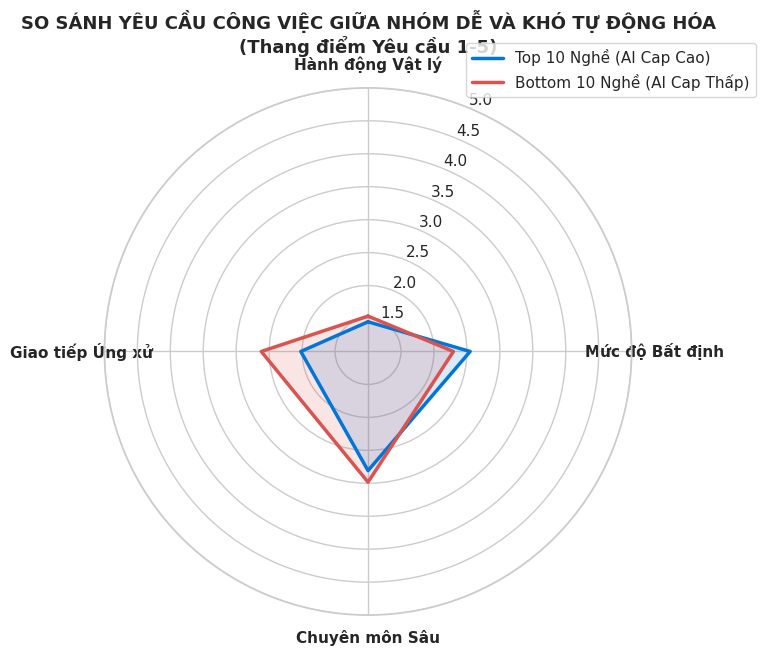

In [ ]:
# BIỂU ĐỒ 3 — PHÂN TÍCH YẾU TỐ RẢO CẢNG TỰ ĐỘNG HÓA (4 CHALLENGE DIMENSIONS)
# Tính điểm trung bình của 4 chiều thử thách kỹ thuật đối với Top 10 Cap vs Bottom 10 Cap
challenge_cols = [
    "Physical Action Requirement",
    "Involved Uncertainty",
    "Domain Expertise Requirement",
    "Interpersonal Communication Requirement"
]

req_labels = ["Hành động Vật lý", "Mức độ Bất định", "Chuyên môn Sâu", "Giao tiếp Ứng xử"]

# Filter out NaN values from 'Cap_o' before sorting to ensure consistent lists
occ_master_filtered = occ_master.dropna(subset=["Cap_o"]).copy()

# Get top and bottom 10 occupations by 'Cap_o'
top_10_occ_titles = occ_master_filtered.sort_values(by="Cap_o", ascending=False).head(10)["Occupation (O*NET-SOC Title)"].tolist()
bottom_10_occ_titles = occ_master_filtered.sort_values(by="Cap_o", ascending=True).head(10)["Occupation (O*NET-SOC Title)"].tolist()

# Filter master_expert_cap_biz for these top/bottom occupations and calculate mean of challenge dimensions
top_req = master_expert_cap_biz[master_expert_cap_biz["Occupation (O*NET-SOC Title)"].isin(top_10_occ_titles)][challenge_cols].mean().values
bot_req = master_expert_cap_biz[master_expert_cap_biz["Occupation (O*NET-SOC Title)"].isin(bottom_10_occ_titles)][challenge_cols].mean().values

# Vẽ Biểu đồ Radar (Spider Chart)
angles = np.linspace(0, 2 * np.pi, len(challenge_cols), endpoint=False).tolist()
angles += angles[:1]  # Khép kín đường tròn

top_req_closed = np.concatenate((top_req, [top_req[0]]))
bot_req_closed = np.concatenate((bot_req, [bot_req[0]]))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, top_req_closed, color="#0275d8", linewidth=2.5, linestyle="solid", label="Top 10 Nghề (AI Cap Cao)")
ax.fill(angles, top_req_closed, color="#0275d8", alpha=0.15)

ax.plot(angles, bot_req_closed, color="#d9534f", linewidth=2.5, linestyle="solid", label="Bottom 10 Nghề (AI Cap Thấp)")
ax.fill(angles, bot_req_closed, color="#d9534f", alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(req_labels, fontsize=11, fontweight="bold")
ax.set_ylim(1, 5)

plt.title("SO SÁNH YÊU CẦU CÔNG VIỆC GIỮA NHÓM DỄ VÀ KHÓ TỰ ĐỘNG HÓA\n(Thang điểm Yêu cầu 1-5)", fontsize=13, fontweight="bold", pad=25)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.show()

**Tính Worker Readiness Score (Readiness)**

In [ ]:
# TÍNH WORKER READINESS SCORE VÀ THỐNG KÊ LÝ DO (TẬN DỤNG CÁC BIẾN ĐÃ CÓ)

# Directly use occ_master which already contains Cap_o and Read_o
# Create readiness_cap_matrix from occ_master, renaming columns for plotting consistency.
readiness_cap_matrix = occ_master[[
    "Occupation (O*NET-SOC Title)",
    "Cap_o",
    "Read_o",
    "Task_Count" # Task_Count was added to occ_master in qd8ZzuQA2YG1
]].rename(columns={
    "Cap_o": "AI_Capability",
    "Read_o": "Worker_Readiness_Score"
}).copy()

readiness_cap_matrix["Capability_Readiness_Gap"] = (
    readiness_cap_matrix["AI_Capability"] - readiness_cap_matrix["Worker_Readiness_Score"]
)

# 4. Thống kê Lý do Chấp nhận / Từ chối AI
# This part of the code relies on 'master_worker_desire_biz' and is largely independent of 'occ_master' structure.
worker_desire_biz = master_worker_desire_biz.copy() # Use the pre-filtered master_worker_desire_biz

# Xác định các cột chứa lý do chấp nhận
accept_reason_cols = [c for c in worker_desire_biz.columns if "reasons for automation desire - " in c.lower()]
other_accept_col = "Other Reason for Automation Desire"
if other_accept_col in worker_desire_biz.columns:
    # Convert 'FALSE' string to False boolean, treat non-False/non-nan as True
    worker_desire_biz[other_accept_col + '_bool'] = worker_desire_biz[other_accept_col].apply(lambda x: False if pd.isna(x) or str(x).lower() == 'false' else True)
    accept_reason_cols.append(other_accept_col + '_bool')

# Xác định các cột chứa lý do từ chối
reject_reason_cols = [c for c in worker_desire_biz.columns if "reasons for human agency - " in c.lower()]
other_reject_col = "Other Reason for Human Agency"
if other_reject_col in worker_desire_biz.columns:
    # Convert 'FALSE' string to False boolean, treat non-False/non-nan as True
    worker_desire_biz[other_reject_col + '_bool'] = worker_desire_biz[other_reject_col].apply(lambda x: False if pd.isna(x) or str(x).lower() == 'false' else True)
    reject_reason_cols.append(other_reject_col + '_bool')

# Aggregate counts for acceptance reasons
accept_reasons_overall_counts = worker_desire_biz[accept_reason_cols].sum()
accept_reasons_overall = (accept_reasons_overall_counts / len(worker_desire_biz)) * 100
accept_reasons_overall = accept_reasons_overall.sort_values(ascending=False)

# Aggregate counts for rejection reasons
reject_reasons_overall_counts = worker_desire_biz[reject_reason_cols].sum()
reject_reasons_overall = (reject_reasons_overall_counts / len(worker_desire_biz)) * 100
reject_reasons_overall = reject_reasons_overall.sort_values(ascending=False)

# Thống kê phân rã theo Nhóm ngành (Group 11 vs Group 13)
grouped_reject_data = worker_desire_biz.groupby("major_group")[reject_reason_cols].sum()
total_in_group = worker_desire_biz.groupby("major_group").size()
reject_by_group = (grouped_reject_data.div(total_in_group, axis=0)) * 100
reject_by_group = reject_by_group.fillna(0)

print(f"Đã xử lý xong dữ liệu Sẵn sàng Lao động cho {len(readiness_cap_matrix)} nghề nghiệp.")
print(f"Điểm Readiness trung bình toàn khối ngành: {readiness_cap_matrix['Worker_Readiness_Score'].mean():.2f} / 5.0")

Đã xử lý xong dữ liệu Sẵn sàng Lao động cho 34 nghề nghiệp.
Điểm Readiness trung bình toàn khối ngành: 3.04 / 5.0


**Biểu đồ**

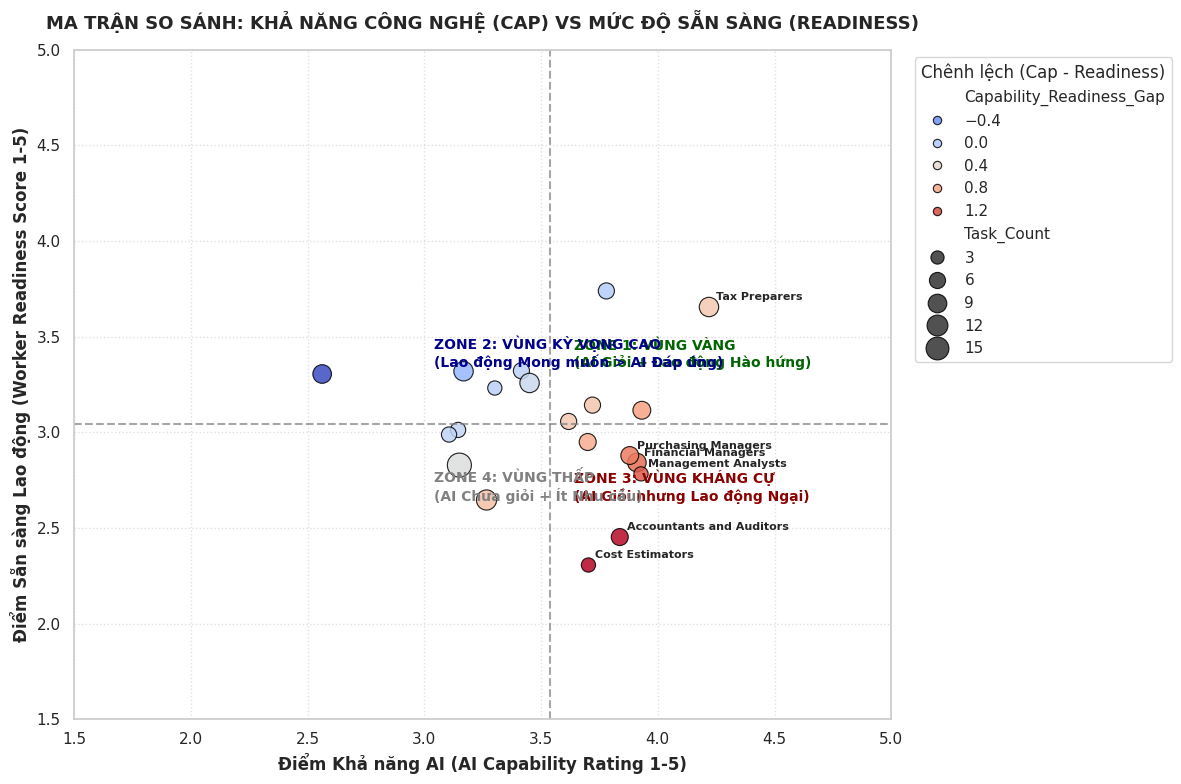

In [ ]:
# MA TRẬN KHẢ NĂNG AI (CAP) VS MỨC ĐỘ SẴN SÀNG (READINESS)

plt.figure(figsize=(12, 8))

# Scatter Plot phân loại nghề nghiệp
ax = sns.scatterplot(
    data=readiness_cap_matrix,
    x="AI_Capability",
    y="Worker_Readiness_Score",
    size="Task_Count",
    sizes=(60, 300),
    hue="Capability_Readiness_Gap",
    palette="coolwarm",
    alpha=0.85,
    edgecolor="black"
)

# Trục gốc phân chia 4 góc phần tư dựa trên median / mean
mean_readiness = readiness_cap_matrix["Worker_Readiness_Score"].mean()

plt.axvline(overall_mean, color="gray", linestyle="--", alpha=0.7)
plt.axhline(mean_readiness, color="gray", linestyle="--", alpha=0.7)

# Ghi chú cho 4 góc phần tư
plt.text(overall_mean + 0.1, mean_readiness + 0.3, "ZONE 1: VÙNG VÀNG\n(AI Giỏi + Lao động Hào hứng)", fontsize=10, fontweight="bold", color="darkgreen")
plt.text(overall_mean - 0.5, mean_readiness + 0.3, "ZONE 2: VÙNG KỲ VỌNG CAO\n(Lao động Mong muốn > AI Đáp ứng)", fontsize=10, fontweight="bold", color="darkblue")
plt.text(overall_mean + 0.1, mean_readiness - 0.4, "ZONE 3: VÙNG KHÁNG CỰ\n(AI Giỏi nhưng Lao động Ngại)", fontsize=10, fontweight="bold", color="darkred")
plt.text(overall_mean - 0.5, mean_readiness - 0.4, "ZONE 4: VÙNG THẤP\n(AI Chưa giỏi + Ít Nhu cầu)", fontsize=10, fontweight="bold", color="gray")

# Annotate các nghề tiêu biểu
for idx, row in readiness_cap_matrix.iterrows():
    if row["AI_Capability"] > 4.2 or row["Worker_Readiness_Score"] < 2.5 or abs(row["Capability_Readiness_Gap"]) > 1.0:
        plt.annotate(
            row["Occupation (O*NET-SOC Title)"],
            (row["AI_Capability"], row["Worker_Readiness_Score"]),
            textcoords="offset points",
            xytext=(5, 5),
            ha="left",
            fontsize=8,
            fontweight="bold"
        )

plt.title("MA TRẬN SO SÁNH: KHẢ NĂNG CÔNG NGHỆ (CAP) VS MỨC ĐỘ SẴN SÀNG (READINESS)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Điểm Khả năng AI (AI Capability Rating 1-5)", fontweight="bold")
plt.ylabel("Điểm Sẵn sàng Lao động (Worker Readiness Score 1-5)", fontweight="bold")
plt.xlim(1.5, 5.0)
plt.ylim(1.5, 5.0)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Chênh lệch (Cap - Readiness)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1683/2464714324.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_accept, x="Percentage", y="Reason", ax=axes[0], palette="Greens_r")
/tmp/ipykernel_1683/2464714324.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_reject, x="Percentage", y="Reason", ax=axes[1], palette="Oranges_r")


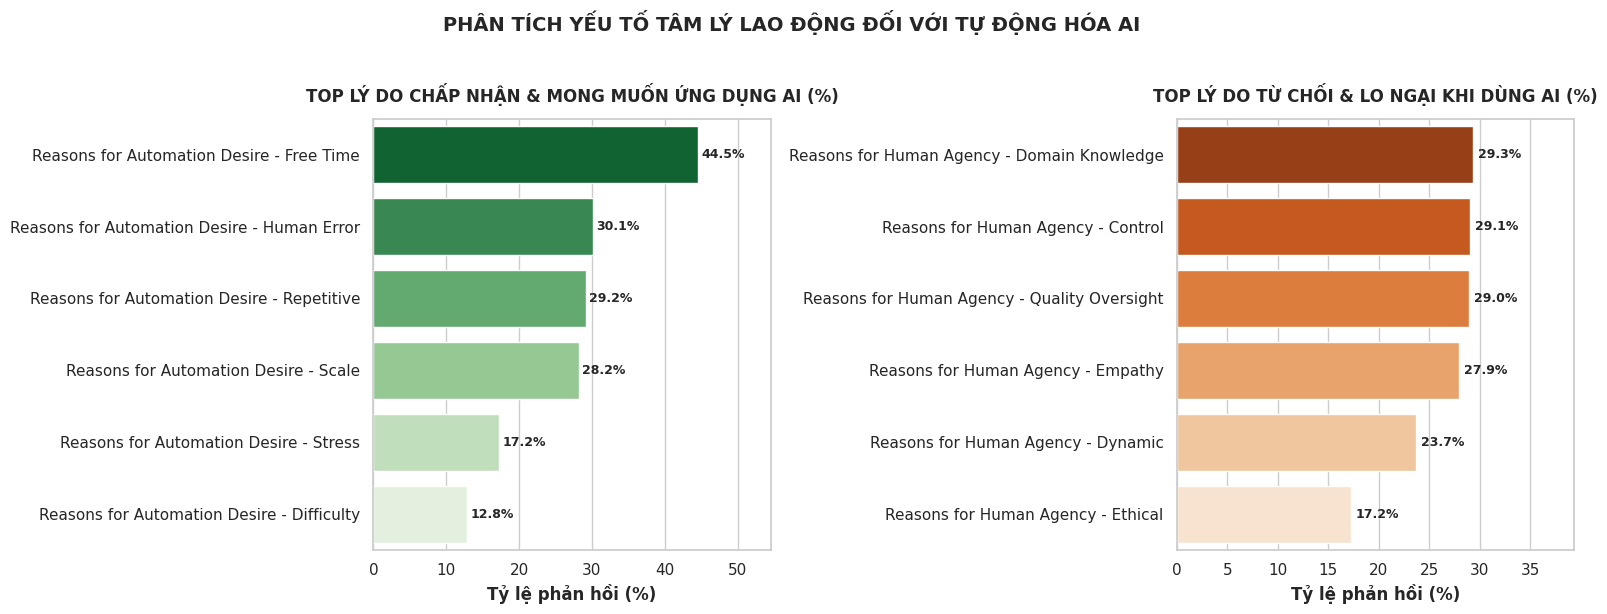

In [ ]:
# TOP LÝ DO CHẤP NHẬN & TỪ CHỐI AI

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top lý do Chấp nhận AI
top_accept = accept_reasons_overall.head(6).reset_index()
top_accept.columns = ["Reason", "Percentage"]

sns.barplot(data=top_accept, x="Percentage", y="Reason", ax=axes[0], palette="Greens_r")
axes[0].set_title("TOP LÝ DO CHẤP NHẬN & MONG MUỐN ỨNG DỤNG AI (%)", fontsize=12, fontweight="bold", pad=12)
axes[0].set_xlabel("Tỷ lệ phản hồi (%)", fontweight="bold")
axes[0].set_ylabel("")

for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{w:.1f}%", (w + 0.5, p.get_y() + p.get_height() / 2.), ha="left", va="center", fontweight="bold", fontsize=9)

# 2. Top lý do Từ chối AI
top_reject = reject_reasons_overall.head(6).reset_index()
top_reject.columns = ["Reason", "Percentage"]

sns.barplot(data=top_reject, x="Percentage", y="Reason", ax=axes[1], palette="Oranges_r")
axes[1].set_title("TOP LÝ DO TỪ CHỐI & LO NGẠI KHI DÙNG AI (%)", fontsize=12, fontweight="bold", pad=12)
axes[1].set_xlabel("Tỷ lệ phản hồi (%)", fontweight="bold")
axes[1].set_ylabel("")

for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.1f}%", (w + 0.5, p.get_y() + p.get_height() / 2.), ha="left", va="center", fontweight="bold", fontsize=9)

axes[0].set_xlim(0, max(top_accept["Percentage"]) + 10)
axes[1].set_xlim(0, max(top_reject["Percentage"]) + 10)

plt.suptitle("PHÂN TÍCH YẾU TỐ TÂM LÝ LAO ĐỘNG ĐỐI VỚI TỰ ĐỘNG HÓA AI", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

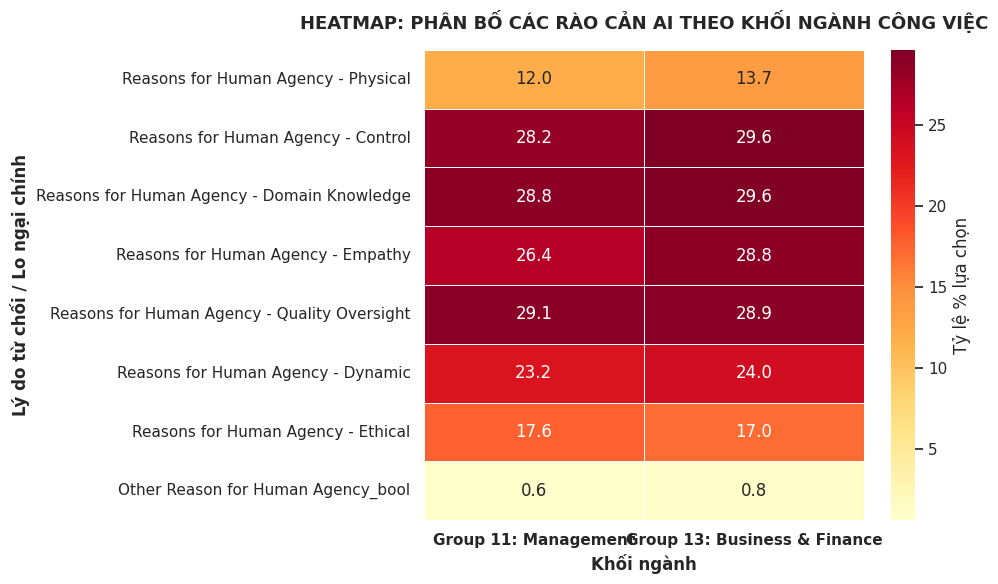

In [ ]:
# HEATMAP SO SÁNH RÀO CẢN GIỮA NGHÀNH QUẢN LÝ (11) VS TÀI CHÍNH (13)

plt.figure(figsize=(10, 6))

sns.heatmap(
    reject_by_group.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Tỷ lệ % lựa chọn'},
    linewidths=0.5
)

plt.xticks(
    ticks=[0.5, 1.5],
    labels=["Group 11: Management", "Group 13: Business & Finance"],
    fontweight="bold"
)

plt.title("HEATMAP: PHÂN BỐ CÁC RÀO CẢN AI THEO KHỐI NGÀNH CÔNG VIỆC", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Khối ngành", fontweight="bold")
plt.ylabel("Lý do từ chối / Lo ngại chính", fontweight="bold")

plt.tight_layout()
plt.show()

**- Tính Worker Friction Index (WFI = Cap − Read)**

In [ ]:
# TÍNH WFI VÀ TẠO BẢNG TỔNG HỢP CHỈ SỐ THEO OCCUPATION

# 1. Directly use WFI from occ_master (which is Cap_norm - Read_norm)
# No need to recalculate Worker_Friction_Index

# 2. Định nghĩa hàm phân loại mức độ Friction (using the WFI from occ_master, which is Cap_norm - Read_norm)
def categorize_friction(wfi):
    if wfi > 0.8: # Thresholds for normalized WFI
        return "High Resistance Risk (Kháng cự cao)"
    elif wfi < -0.8: # Thresholds for normalized WFI
        return "Demand Pull (Kỳ vọng cao)"
    else:
        return "Balanced Alignment (Cân bằng)"

# Construct occupation_metrics from occ_master
occupation_metrics = occ_master[[
    "O*NET-SOC Code", # Keep O*NET-SOC Code for potential future joins
    "Occupation (O*NET-SOC Title)",
    "Cap_o", # Raw Cap_o score
    "Read_o", # Raw Read_o score
    "WFI", # Normalized WFI (Cap_norm - Read_norm)
    "Task_Count"
]].rename(
    columns={
        "Occupation (O*NET-SOC Title)": "Occupation",
        "Cap_o": "Cap_Score",
        "Read_o": "Read_Score"
    }
).copy()

occupation_metrics["Friction_Category"] = occupation_metrics["WFI"].apply(categorize_friction)

# Sort by WFI
occupation_metrics = occupation_metrics.sort_values(by="WFI", ascending=False).reset_index(drop=True)

# 4. Xuất dữ liệu ra file CSV để lưu trữ và phục vụ báo cáo / dashboard
occupation_metrics.to_csv("occupation_wfi_metrics.csv", index=False, encoding="utf-8-sig")

print("--- TOP 5 NGHỀ CÓ WORKER FRICTION INDEX (WFI) CAO NHẤT (RỦI RO KHÁNG CỰ CAO) ---")
display(occupation_metrics.head(5))

print("\n--- TOP 5 NGHỀ CÓ WORKER FRICTION INDEX (WFI) THẤP NHẤT (NHU CẦU KÉO CAO) ---")
display(occupation_metrics.tail(5))

print(f"\nĐã lưu thành công tập chỉ số '{len(occupation_metrics)} Nghề nghiệp' vào file 'occupation_wfi_metrics.csv'.")

--- TOP 5 NGHỀ CÓ WORKER FRICTION INDEX (WFI) CAO NHẤT (RỦI RO KHÁNG CỰ CAO) ---


,O*NET-SOC Code,Occupation,Cap_Score,Read_Score,WFI,Task_Count,Friction_Category
0,13-1051.00,Cost Estimators,3.703051,2.306387,0.688381,4.0,Balanced Alignment (Cân bằng)
1,13-2011.00,Accountants and Auditors,3.837200,2.452569,0.667358,7.0,Balanced Alignment (Cân bằng)
2,13-1111.00,Management Analysts,3.928199,2.782880,0.491795,4.0,Balanced Alignment (Cân bằng)
3,11-3031.00,Financial Managers,3.910435,2.842245,0.439644,9.0,Balanced Alignment (Cân bằng)
4,11-3061.00,Purchasing Managers,3.879976,2.878950,0.395643,8.0,Balanced Alignment (Cân bằng)



--- TOP 5 NGHỀ CÓ WORKER FRICTION INDEX (WFI) THẤP NHẤT (NHU CẦU KÉO CAO) ---


,O*NET-SOC Code,Occupation,Cap_Score,Read_Score,WFI,Task_Count,Friction_Category
29,13-1081.00,Logisticians,NaN,NaN,NaN,4.0,Balanced Alignment (Cân bằng)
30,13-1141.00,"Compensation, Benefits, and Job Analysis Speci...",NaN,NaN,NaN,2.0,Balanced Alignment (Cân bằng)
31,13-1161.00,Market Research Analysts and Marketing Special...,NaN,NaN,NaN,4.0,Balanced Alignment (Cân bằng)
32,13-2053.00,Insurance Underwriters,NaN,NaN,NaN,4.0,Balanced Alignment (Cân bằng)
33,13-2081.00,"Tax Examiners and Collectors, and Revenue Agents",NaN,NaN,NaN,12.0,Balanced Alignment (Cân bằng)



Đã lưu thành công tập chỉ số '34 Nghề nghiệp' vào file 'occupation_wfi_metrics.csv'.


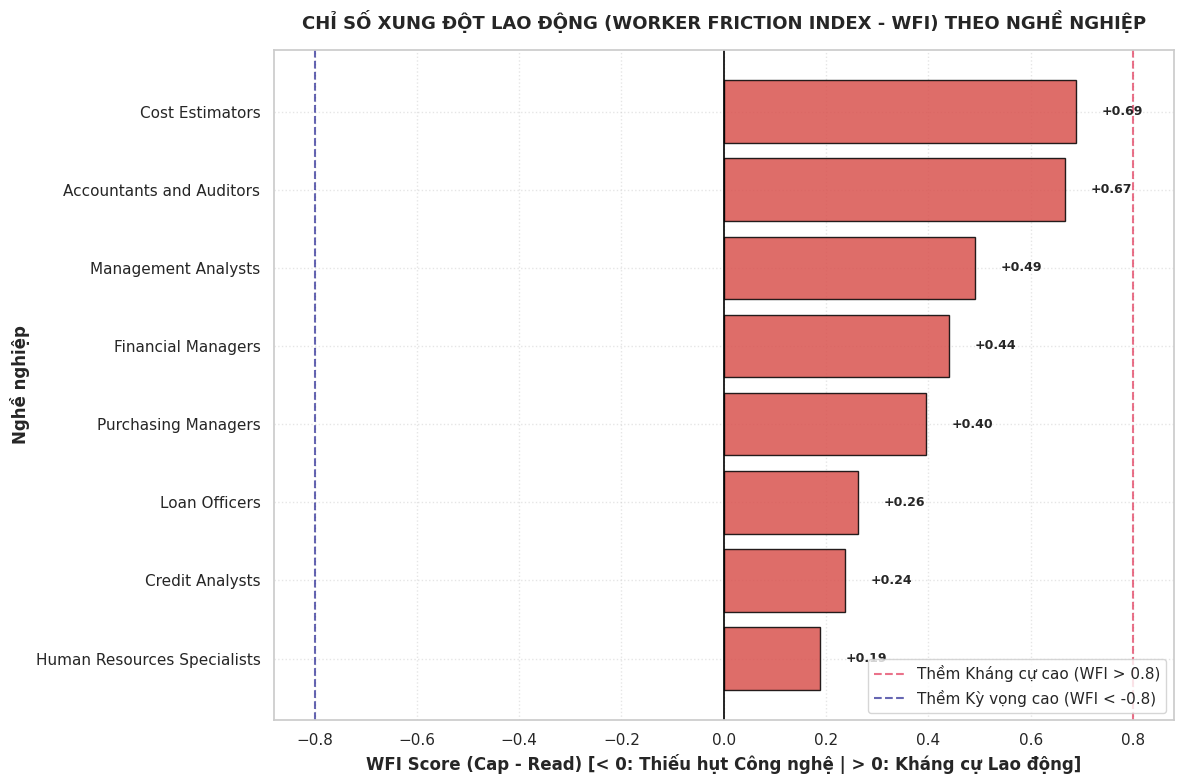

In [ ]:
# TRỰC QUAN HÓA WORKER FRICTION INDEX (DIVERGING BAR CHART)

# Chọn Top 8 nghề có WFI cao nhất và Top 8 nghề có WFI thấp nhất để so sánh
top_wfi = occupation_metrics.head(8)
bot_wfi = occupation_metrics.tail(8)
wfi_plot_data = pd.concat([top_wfi, bot_wfi]).sort_values(by="WFI", ascending=True)

plt.figure(figsize=(12, 8))

# Gán màu sắc phân biệt giá trị WFI âm/dương
colors = ["#d9534f" if x > 0 else "#0275d8" for x in wfi_plot_data["WFI"]]

bars = plt.barh(wfi_plot_data["Occupation"], wfi_plot_data["WFI"], color=colors, alpha=0.85, edgecolor="black")

# Vạch ranh giới WFI = 0
plt.axvline(0, color="black", linestyle="-", linewidth=1.2)
plt.axvline(0.8, color="crimson", linestyle="--", alpha=0.6, label="Thềm Kháng cự cao (WFI > 0.8)")
plt.axvline(-0.8, color="navy", linestyle="--", alpha=0.6, label="Thềm Kỳ vọng cao (WFI < -0.8)")

# Ghi giá trị WFI lên đầu thanh bar
for bar in bars:
    w = bar.get_width()
    offset = 0.05 if w >= 0 else -0.18
    plt.text(
        w + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{w:+.2f}",
        va="center",
        fontweight="bold",
        fontsize=9
    )

plt.title("CHỈ SỐ XUNG ĐỘT LAO ĐỘNG (WORKER FRICTION INDEX - WFI) THEO NGHỀ NGHIỆP", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("WFI Score (Cap - Read) [< 0: Thiếu hụt Công nghệ | > 0: Kháng cự Lao động]", fontweight="bold")
plt.ylabel("Nghề nghiệp", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

**Câu hỏi cần trả lời**

* AI Agent hiện nay có thể tự động hóa những nghề nào?

* Người lao động có sẵn sàng hợp tác với AI hay không?
* Khoảng cách giữa năng lực AI và mức độ sẵn sàng của người lao động lớn đến đâu?


---


Insight cần rút ra: Xác định các nghề có AI mạnh nhưng con người chưa sẵn sàng (rủi ro phản kháng), các nghề AI và con người đồng thuận (cơ hội triển khai ngay), và các nghề AI còn hạn chế (tiếp tục Human-Centric).

**1. AI Agent hiện nay có thể tự động hóa những nghề nào?**

Dựa trên điểm Năng lực Kỹ thuật (Automation Capacity Rating) được đánh giá bởi các chuyên gia công nghệ:

  * ***Các nghề AI Agent tự động hóa rất tốt (Điểm Capacity > 4.0 / 5.0):***
    * Medical Transcriptionists (4.88/5), Travel Agents (4.63/5), Payroll & Timekeeping Clerks (4.56/5), Bookkeeping, Accounting, and Auditing Clerks (4.41/5), Online Merchants (4.28/5), Customer Service Representatives (4.26/5), Tax Preparers (4.20/5).  
    * Đặc điểm tác vụ: Đòi hỏi thao tác vật lý rất thấp (Physical Action trung bình chỉ 1.70/5), làm việc trên dữ liệu cấu trúc, tuân thủ quy trình chuẩn hóa và ít yêu cầu giao tiếp ứng biến phức tạp.  
  * ***Các nghề AI Agent còn rất hạn chế (Điểm Capacity < 2.7 / 5.0):***
    * Computer and Information Systems Managers (2.56/5), Regulatory Affairs Managers (2.64/5), Transportation Planners (2.50/5), Art Directors (2.21/5).  
    * Đặc điểm tác vụ: Yêu cầu mức độ bất định cao (Involved Uncertainty ~ 2.42/5), tri thức ngành sâu (Domain Expertise ~ 3.08/5) và kỹ năng lãnh đạo/giao tiếp chiến lược (Interpersonal Communication).

# **Các chỉ số Rủi ro Mở rộng: WEI, PEI, CI**
`WEI` và `PEI` đã được tính sẵn trong bước tổng hợp Occupation-level ở trên
(`occ_master["WEI"]`, `occ_master["PEI"]`); ở đây ta tính bổ sung **Criticality Index (CI)**.

In [ ]:
# Tính CI (Criticality Index) — mức độ quan trọng của tác vụ x khả năng AI
occ_master["CI"] = occ_master["Importance_o_norm"] * occ_master["Cap_norm"]

# Kiểm tra lại phân phối của các chỉ số WEI / PEI / CI
print(occ_master[["Occupation (O*NET-SOC Title)", "WEI", "PEI", "CI"]].describe())


             WEI        PEI         CI
count  20.000000  20.000000  20.000000
mean    0.158556   0.234531   0.382956
std     0.204850   0.210564   0.178028
min     0.000000   0.000000   0.000000
25%     0.024428   0.074994   0.264660
50%     0.082432   0.175153   0.364912
75%     0.210903   0.364885   0.530305
max     0.769367   0.767265   0.789862


Ý nghĩa của các chỉ số CI, WEI và PEI đối với rủi ro nghề nghiệp, giúp đánh giá mức độ ảnh hưởng của AI đến các công việc:
1. **CI (Criticality Index - Chỉ số Quan trọng):**

- **Ý nghĩa:** CI đo lường rủi ro kiểm soát của một nghề nghiệp do khả năng AI thực hiện các nhiệm vụ quan trọng trong nghề đó. Nó được tính bằng cách nhân mức độ quan trọng trung bình được chuẩn hóa của các tác vụ trong nghề với khả năng tự động hóa được chuẩn hóa của nghề nghiệp đó.
- **Đối với rủi ro nghề nghiệp:** Một CI cao cho thấy các nhiệm vụ cốt lõi, quan trọng của một nghề nghiệp có khả năng cao bị AI tự động hóa. Điều này hàm ý rủi ro lớn hơn về sự thay đổi cơ bản trong yêu cầu công việc hoặc thậm chí là nguy cơ thay thế một phần đáng kể vai trò của con người trong các nhiệm vụ quan trọng, đòi hỏi tổ chức phải có kế hoạch tái đào tạo hoặc tái phân bổ nguồn lực.

2. **WEI (Workforce Exposure Index - Chỉ số Tiếp xúc Lực lượng Lao động):**

- **Ý nghĩa:** WEI định lượng tổng quy mô lực lượng lao động trong một nghề nghiệp có khả năng bị ảnh hưởng bởi năng lực của AI. Nó được tính bằng cách nhân mức độ việc làm được chuẩn hóa của nghề nghiệp với khả năng tự động hóa được chuẩn hóa của nghề nghiệp đó.
- **Đối với rủi ro nghề nghiệp:** Một WEI cao chỉ ra rằng một số lượng lớn người lao động trong ngành đó sẽ bị tác động bởi AI. Điều này có thể dẫn đến những thách thức lớn về quản lý nhân sự, nhu cầu đào tạo lại trên quy mô lớn, hoặc nguy cơ thất nghiệp đối với một phân khúc đáng kể của lực lượng lao động nếu không có sự chuẩn bị kịp thời.

3. **PEI (Payroll Exposure Index - Chỉ số Tiếp xúc Bảng lương):**

- **Ý nghĩa:** PEI đo lường tổng chi phí lương bổng trong một nghề nghiệp có khả năng bị ảnh hưởng bởi AI. Nó được tính bằng cách nhân mức lương trung bình hàng năm được chuẩn hóa của nghề nghiệp với khả năng tự động hóa được chuẩn hóa của nghề nghiệp đó.

- **Đối với rủi ro nghề nghiệp:** Một PEI cao chỉ ra rằng một phần lớn ngân sách lương bổng của tổ chức đang gắn liền với các công việc có khả năng bị AI tự động hóa. Điều này không chỉ liên quan đến rủi ro về chi phí mà còn về chiến lược phân bổ vốn, buộc các tổ chức phải cân nhắc lại việc đầu tư vào tự động hóa để tối ưu hóa chi phí hoặc tái đầu tư vào các lĩnh vực khác để nâng cao giá trị của con người.

## BIỂU ĐỒ: TOP & BOTTOM 10 OCCUPATIONS BY CRITICALITY INDEX (CI)

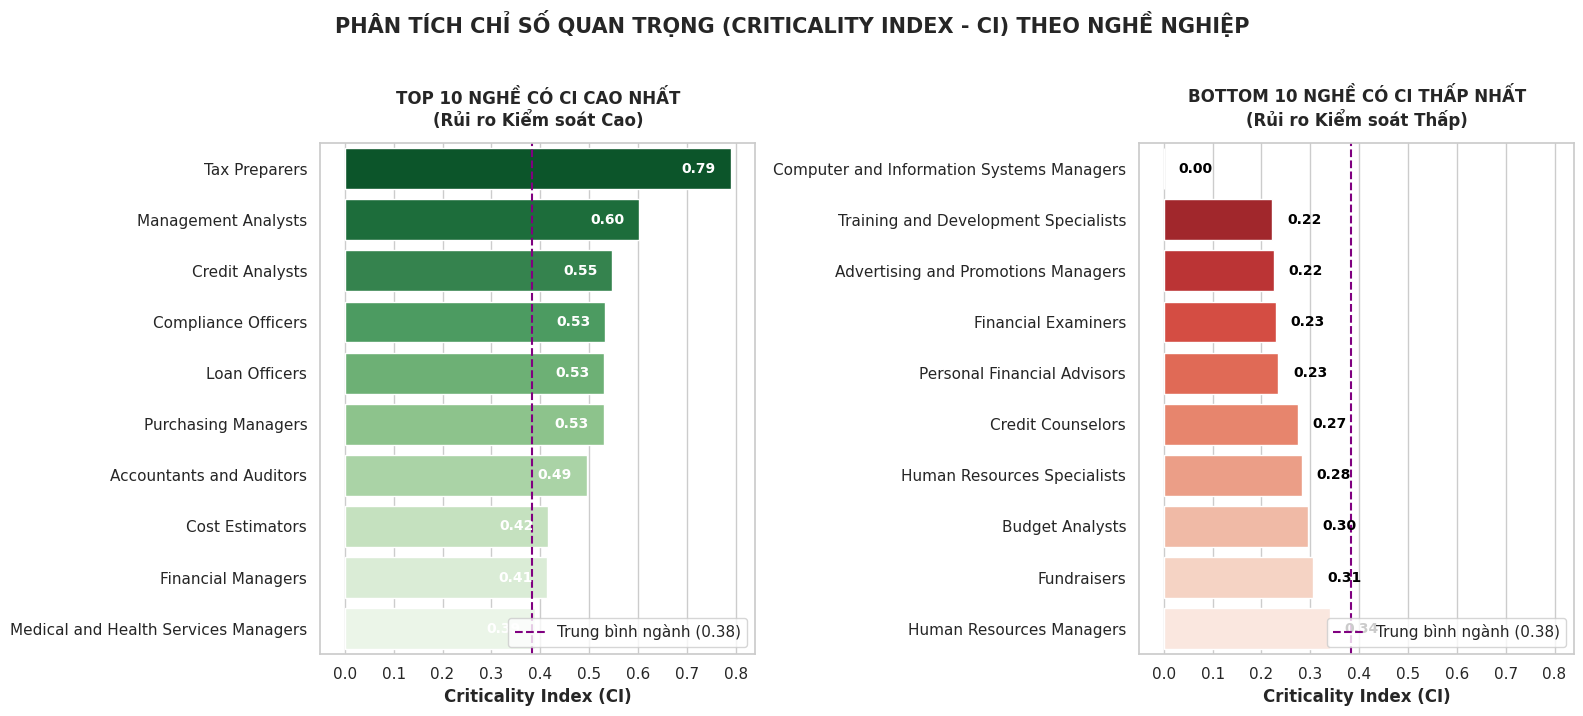

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# Filter out NaN values from 'CI' before sorting
occ_master_filtered_ci = occ_master.dropna(subset=["CI"]).copy()

# Calculate overall mean from the filtered data
overall_mean_ci = occ_master_filtered_ci["CI"].mean()

# Derive top and bottom 10 occupations from occ_master_filtered_ci
top_10_occ_ci = occ_master_filtered_ci.sort_values(by="CI", ascending=False).head(10)
bottom_10_occ_ci = occ_master_filtered_ci.sort_values(by="CI", ascending=True).head(10)

# Barplot Top 10 Occupations (High CI)
sns.barplot(
    data=top_10_occ_ci,
    x="CI",
    y="Occupation (O*NET-SOC Title)",
    ax=axes[0],
    palette="Greens_r",
    hue="Occupation (O*NET-SOC Title)",
    legend=False
)
axes[0].set_title("TOP 10 NGHỀ CÓ CI CAO NHẤT\n(Rủi ro Kiểm soát Cao)", fontsize=12, fontweight="bold", pad=12)
axes[0].set_xlabel("Criticality Index (CI)", fontweight="bold")
axes[0].set_ylabel("")
axes[0].axvline(overall_mean_ci, color="purple", linestyle="--", linewidth=1.5, label=f"Trung bình ngành ({overall_mean_ci:.2f})")
axes[0].legend(loc="lower right")

# Hiển thị nhãn giá trị trên thanh bar Top 10
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f"{width:.2f}", (width - 0.03, p.get_y() + p.get_height() / 2.),
                     ha="right", va="center", color="white", fontweight="bold", fontsize=10)

# Barplot Bottom 10 Occupations (Low CI)
sns.barplot(
    data=bottom_10_occ_ci,
    x="CI",
    y="Occupation (O*NET-SOC Title)",
    ax=axes[1],
    palette="Reds_r",
    hue="Occupation (O*NET-SOC Title)",
    legend=False
)
axes[1].set_title("BOTTOM 10 NGHỀ CÓ CI THẤP NHẤT\n(Rủi ro Kiểm soát Thấp)", fontsize=12, fontweight="bold", pad=12)
axes[1].set_xlabel("Criticality Index (CI)", fontweight="bold")
axes[1].set_ylabel("")
axes[1].axvline(overall_mean_ci, color="purple", linestyle="--", linewidth=1.5, label=f"Trung bình ngành ({overall_mean_ci:.2f})")
axes[1].legend(loc="lower right")

# Hiển thị nhãn giá trị trên thanh bar Bottom 10
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f"{width:.2f}", (width + 0.03, p.get_y() + p.get_height() / 2.),
                     ha="left", va="center", color="black", fontweight="bold", fontsize=10)

# Set consistent x-limits
max_ci = occ_master_filtered_ci["CI"].max()
min_ci = occ_master_filtered_ci["CI"].min()
axes[0].set_xlim(min_ci - 0.05, max_ci + 0.05)
axes[1].set_xlim(min_ci - 0.05, max_ci + 0.05)

plt.suptitle("PHÂN TÍCH CHỈ SỐ QUAN TRỌNG (CRITICALITY INDEX - CI) THEO NGHỀ NGHIỆP", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Biểu đồ đã được tạo thành công, thể hiện Top 10 nghề nghiệp có Chỉ số quan trọng (Criticality Index - CI) cao nhất và thấp nhất. Điều này giúp chúng ta nhận diện những nghề có rủi ro kiểm soát cao (dễ bị AI tác động đến các nhiệm vụ quan trọng) và những nghề có rủi ro thấp hơn. Đường tham chiếu màu tím thể hiện CI trung bình của toàn bộ các ngành được phân tích, giúp chúng ta so sánh vị trí của từng nghề nghiệp so với mức trung bình.

In [ ]:
print("--- TOP 10 NGHỀ CÓ TÁC ĐỘNG QUỸ LƯƠNG LỚN NHẤT (HIGHEST PEI) ---")
# Sắp xếp occ_master theo PEI giảm dần và chọn 10 nghề đứng đầu
top_10_pei = occ_master.sort_values(by='PEI', ascending=False).head(10)
display(top_10_pei[['Occupation (O*NET-SOC Title)', 'PEI', 'Wage_norm', 'Cap_norm']])
print("\n*Lưu ý cho CFO (Giám đốc Tài chính):* Các nghề này có chi phí lương bổng chịu tác động lớn nhất từ AI. Cần xem xét chiến lược phân bổ vốn và tái đầu tư.")

print("\n--- TOP 10 NGHỀ CÓ TÁC ĐỘNG VIỆC LÀM LỚN NHẤT (HIGHEST WEI) ---")
# Sắp xếp occ_master theo WEI giảm dần và chọn 10 nghề đứng đầu
top_10_wei = occ_master.sort_values(by='WEI', ascending=False).head(10)
display(top_10_wei[['Occupation (O*NET-SOC Title)', 'WEI', 'Employment_norm', 'Cap_norm']])
print("\n*Lưu ý cho CHRO (Giám đốc Nhân sự):* Các nghề này có số lượng lớn người lao động sẽ bị ảnh hưởng bởi AI. Cần có kế hoạch đào tạo lại và quản lý chuyển đổi nguồn nhân lực hiệu quả.")

--- TOP 10 NGHỀ CÓ TÁC ĐỘNG QUỸ LƯƠNG LỚN NHẤT (HIGHEST PEI) ---


,Occupation (O*NET-SOC Title),PEI,Wage_norm,Cap_norm
4,Financial Managers,0.767265,0.943073,0.813579
5,Purchasing Managers,0.570298,0.717184,0.795191
7,Human Resources Managers,0.553325,0.791749,0.698864
11,Medical and Health Services Managers,0.394766,0.619531,0.637201
19,Management Analysts,0.367037,0.445269,0.824303
0,Advertising and Promotions Managers,0.364168,0.706889,0.515170
27,Personal Financial Advisors,0.277513,0.789705,0.351414
24,Accountants and Auditors,0.219162,0.284860,0.769367
26,Credit Analysts,0.219042,0.319076,0.686487
31,Loan Officers,0.188502,0.228085,0.826458



*Lưu ý cho CFO (Giám đốc Tài chính):* Các nghề này có chi phí lương bổng chịu tác động lớn nhất từ AI. Cần xem xét chiến lược phân bổ vốn và tái đầu tư.

--- TOP 10 NGHỀ CÓ TÁC ĐỘNG VIỆC LÀM LỚN NHẤT (HIGHEST WEI) ---


,Occupation (O*NET-SOC Title),WEI,Employment_norm,Cap_norm
24,Accountants and Auditors,0.769367,1.000000,0.769367
19,Management Analysts,0.507062,0.615141,0.824303
4,Financial Managers,0.457948,0.562881,0.813579
17,Human Resources Specialists,0.268275,0.631496,0.424824
11,Medical and Health Services Managers,0.246852,0.387400,0.637201
15,Compliance Officers,0.198920,0.270725,0.734767
31,Loan Officers,0.162216,0.196279,0.826458
22,Training and Development Specialists,0.108807,0.297688,0.365507
16,Cost Estimators,0.101185,0.146991,0.688381
7,Human Resources Managers,0.100781,0.144207,0.698864



*Lưu ý cho CHRO (Giám đốc Nhân sự):* Các nghề này có số lượng lớn người lao động sẽ bị ảnh hưởng bởi AI. Cần có kế hoạch đào tạo lại và quản lý chuyển đổi nguồn nhân lực hiệu quả.


## BIỂU ĐỒ: HEATMAP MỐI TƯƠNG QUAN GIỮA CI, WEI, VÀ PEI

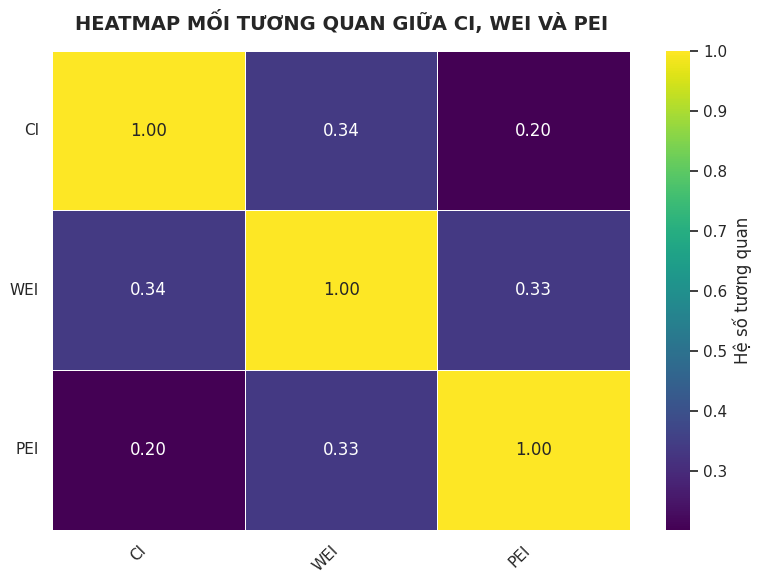

In [ ]:
plt.figure(figsize=(8, 6))

# Chọn các cột chỉ số cần phân tích tương quan
correlation_data = occ_master[['CI', 'WEI', 'PEI']]

# Tính toán ma trận tương quan
corr_matrix = correlation_data.corr()

# Vẽ heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Hệ số tương quan'}
)

plt.title('HEATMAP MỐI TƯƠNG QUAN GIỮA CI, WEI VÀ PEI', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- **CI và WEI có mối tương quan thuận trung bình (khoảng 0.34):** Điều này cho thấy khi chỉ số quan trọng (CI) của một nghề nghiệp tăng lên (tức là rủi ro kiểm soát cao hơn do khả năng AI thay thế các nhiệm vụ quan trọng), thì mức độ tiếp xúc của lực lượng lao động (WEI) trong nghề đó cũng có xu hướng tăng nhẹ. Nghĩa là, các nghề có nhiều nhiệm vụ quan trọng dễ bị AI tác động cũng thường có số lượng lao động lớn hơn, làm tăng tổng thể sự tiếp xúc của lực lượng lao động với AI.

- **CI và PEI có mối tương quan thuận yếu hơn (khoảng 0.20):** Mối quan hệ giữa CI và tổng chi phí lương bổng bị ảnh hưởng bởi AI (PEI) là khá yếu. Điều này có thể chỉ ra rằng các nghề có nhiệm vụ quan trọng dễ bị AI tác động không nhất thiết phải là các nghề có mức lương cao hoặc chi phí lương lớn. Hoặc các nghề có mức lương cao có thể có nhiều nhiệm vụ không quan trọng mà AI có thể thực hiện, làm giảm tổng thể PEI so với CI.

- **WEI và PEI có mối tương quan thuận trung bình (khoảng 0.33):** Các nghề nghiệp có tổng số lượng lao động lớn bị ảnh hưởng bởi AI (WEI) cũng có xu hướng có tổng chi phí lương bổng bị ảnh hưởng bởi AI (PEI) cao hơn. Điều này là hợp lý vì cả hai chỉ số đều chịu ảnh hưởng bởi số lượng lao động và khả năng AI thay thế.

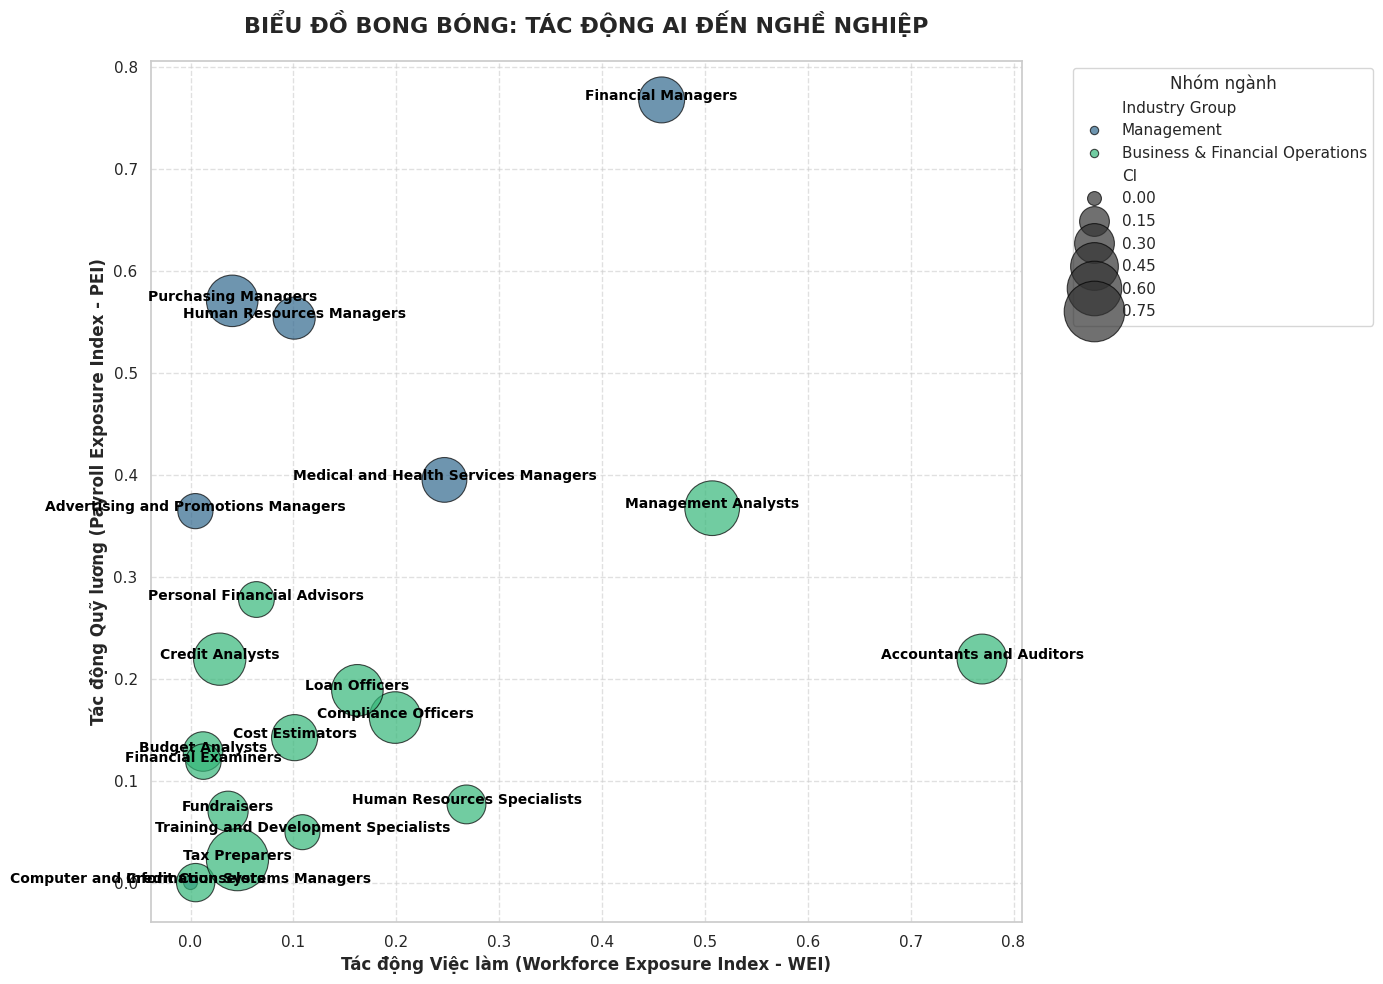

In [ ]:
plt.figure(figsize=(14, 10))

# Lọc bỏ các giá trị NaN trong các cột quan trọng cho biểu đồ và reset index
plot_data = occ_master.dropna(subset=['WEI', 'PEI', 'CI', 'Industry Group']).reset_index(drop=True).copy()

# Tạo biểu đồ bong bóng
sns.scatterplot(
    data=plot_data,
    x='WEI',
    y='PEI',
    size='CI',
    hue='Industry Group',
    sizes=(100, 2000),  # Kích thước bong bóng từ nhỏ đến lớn
    alpha=0.7,
    palette='viridis',
    edgecolor='black',
    linewidth=0.8
)

# Thêm nhãn cho các bong bóng
for line in range(0, plot_data.shape[0]):
     plt.text(
         plot_data.WEI[line],
         plot_data.PEI[line],
         plot_data['Occupation (O*NET-SOC Title)'][line],
         horizontalalignment='center',
         size='small',
         color='black',
         weight='semibold',
         wrap=True # Để nhãn tự động xuống dòng nếu dài
     )

plt.title('BIỂU ĐỒ BONG BÓNG: TÁC ĐỘNG AI ĐẾN NGHỀ NGHIỆP', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tác động Việc làm (Workforce Exposure Index - WEI)', fontsize=12, fontweight='bold')
plt.ylabel('Tác động Quỹ lương (Payroll Exposure Index - PEI)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Nhóm ngành', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## SO SÁNH ĐẶC ĐIỂM RỦI RO GIỮA CÁC NHÓM NGÀNH

In [ ]:
#SO SÁNH ĐẶC ĐIỂM RỦI RO GIỮA CÁC NHÓM NGÀNH
# Group by Industry Group and calculate the mean of relevant metrics
# Ensure to dropna for relevant columns before calculating mean to avoid NaN propagation

risk_comparison_by_group = occ_master.groupby("Industry Group")[['Cap_o', 'Read_o', 'CI', 'WEI', 'PEI']].mean().reset_index()

print("Bảng so sánh các chỉ số rủi ro trung bình theo Nhóm ngành:")
display(risk_comparison_by_group)


Bảng so sánh các chỉ số rủi ro trung bình theo Nhóm ngành:


,Industry Group,Cap_o,Read_o,CI,WEI,PEI
0,Business & Financial Operations,3.549164,3.020515,0.411494,0.165731,0.145772
1,Management,3.518005,3.091265,0.316367,0.141815,0.441637


Giải thích:
- **Cap_o**: Điểm Khả năng AI (trung bình) - Mức độ dễ tự động hóa của các tác vụ trong ngành.
- **Read_o**: Điểm Sẵn sàng của Lao động (trung bình) - Mức độ mong muốn tự động hóa của người lao động trong ngành.
- **CI**: Criticality Index (trung bình) - Rủi ro kiểm soát khi AI thực hiện các tác vụ quan trọng.
- **WEI**: Workforce Exposure Index (trung bình) - Tổng quy mô lực lượng lao động bị ảnh hưởng bởi AI.
- **PEI**: Payroll Exposure Index (trung bình) - Tổng chi phí lương bổng bị ảnh hưởng bởi AI.

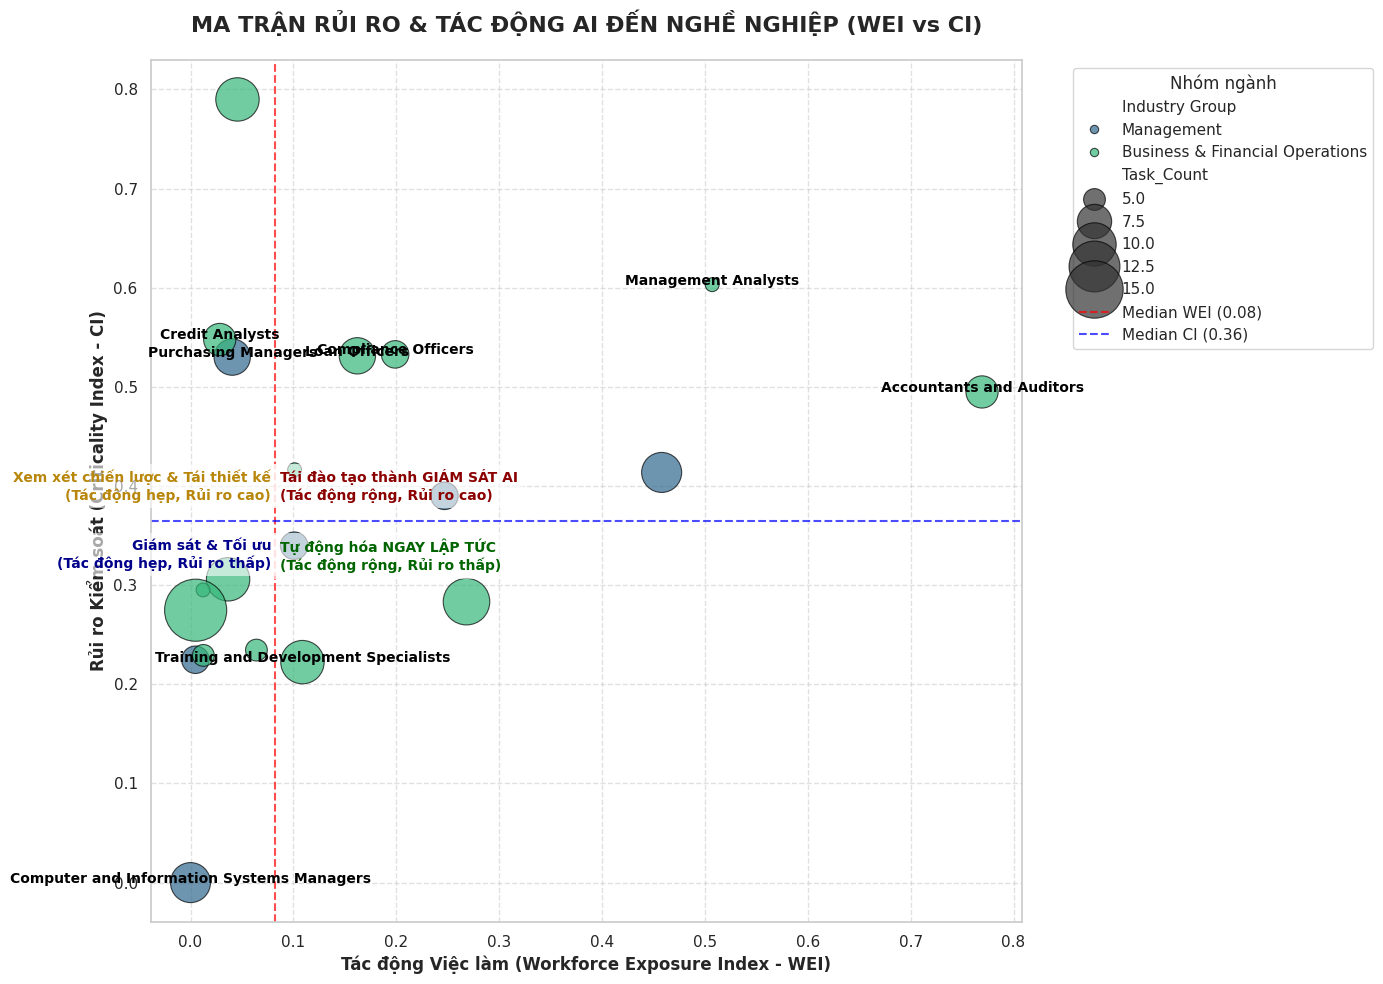

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 10))

# Lọc bỏ các giá trị NaN trong các cột quan trọng cho biểu đồ và reset index
plot_data_risk_impact = occ_master.dropna(subset=['WEI', 'CI', 'Occupation (O*NET-SOC Title)', 'Industry Group']).reset_index(drop=True).copy()

# Tính median cho WEI và CI từ dữ liệu đã lọc
median_wei = plot_data_risk_impact['WEI'].median()
median_ci = plot_data_risk_impact['CI'].median()

# Tạo biểu đồ Scatter Plot
ax = sns.scatterplot(
    data=plot_data_risk_impact,
    x='WEI',
    y='CI',
    size='Task_Count', # Kích thước bong bóng dựa trên số lượng Task
    hue='Industry Group', # Màu sắc phân biệt theo nhóm ngành
    sizes=(100, 2000),  # Kích thước bong bóng từ nhỏ đến lớn
    alpha=0.7,
    palette='viridis',
    edgecolor='black',
    linewidth=0.8
)

# Vẽ đường phân chia (median thresholds)
plt.axvline(median_wei, color='red', linestyle='--', alpha=0.7, label=f'Median WEI ({median_wei:.2f})')
plt.axhline(median_ci, color='blue', linestyle='--', alpha=0.7, label=f'Median CI ({median_ci:.2f})')

# Ghi chú cho 4 góc phần tư
# Góc (WEI cao, CI thấp): Automate immediately
plt.text(median_wei * 1.05, median_ci * 0.95, 'Tự động hóa NGAY LẬP TỨC\n(Tác động rộng, Rủi ro thấp)',
         horizontalalignment='left', verticalalignment='top', fontsize=10, color='darkgreen', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Góc (WEI cao, CI cao): Reskill to AI Overseers
plt.text(median_wei * 1.05, median_ci * 1.05, 'Tái đào tạo thành GIÁM SÁT AI\n(Tác động rộng, Rủi ro cao)',
         horizontalalignment='left', verticalalignment='bottom', fontsize=10, color='darkred', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Góc (WEI thấp, CI thấp): Monitor & Optimize
plt.text(median_wei * 0.95, median_ci * 0.95, 'Giám sát & Tối ưu\n(Tác động hẹp, Rủi ro thấp)',
         horizontalalignment='right', verticalalignment='top', fontsize=10, color='darkblue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# Góc (WEI thấp, CI cao): Strategic Review & Redesign
plt.text(median_wei * 0.95, median_ci * 1.05, 'Xem xét chiến lược & Tái thiết kế\n(Tác động hẹp, Rủi ro cao)',
         horizontalalignment='right', verticalalignment='bottom', fontsize=10, color='darkgoldenrod', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))


# Thêm nhãn cho các bong bóng (chỉ những nghề tiêu biểu hoặc extreme values để tránh chồng chéo)
for index, row in plot_data_risk_impact.iterrows():
    if (row['WEI'] > median_wei and row['CI'] < median_ci * 0.7) or \
       (row['WEI'] > median_wei * 1.2 and row['CI'] > median_ci * 1.2) or \
       (row['WEI'] < median_wei * 0.5 and row['CI'] > median_ci) or \
       (row['WEI'] < median_wei * 0.5 and row['CI'] < median_ci * 0.5):
        plt.text(
            row['WEI'],
            row['CI'],
            row['Occupation (O*NET-SOC Title)'],
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold',
            wrap=True
        )

plt.title('MA TRẬN RỦI RO & TÁC ĐỘNG AI ĐẾN NGHỀ NGHIỆP (WEI vs CI)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tác động Việc làm (Workforce Exposure Index - WEI)', fontsize=12, fontweight='bold')
plt.ylabel('Rủi ro Kiểm soát (Criticality Index - CI)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Nhóm ngành', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Biểu đồ ma trận Rủi ro & Tác động (WEI vs CI) đã được tạo thành công! Biểu đồ này chia các nghề nghiệp thành bốn góc phần tư dựa trên giá trị trung vị của Tác động Việc làm (WEI) và Rủi ro Kiểm soát (CI), giúp chúng ta đưa ra các quyết định chiến lược về ứng dụng AI:

- **Góc trên bên phải (WEI cao, CI cao - Vùng Tái đào tạo/Giám sát AI):** Các nghề trong khu vực này có cả tác động đến lực lượng lao động lớn và rủi ro kiểm soát cao khi AI thực hiện các tác vụ quan trọng. Đây là vùng cần sự chuyển đổi chiến lược, tập trung vào việc tái đào tạo nhân sự hiện tại thành người giám sát AI thay vì thay thế hoàn toàn.

- **Góc dưới bên phải (WEI cao, CI thấp - Vùng Tự động hóa ngay lập tức):** Các nghề nghiệp ở đây có tác động rộng rãi đến lực lượng lao động nhưng rủi ro kiểm soát thấp. Đây là khu vực lý tưởng để triển khai AI tự động hóa hoàn toàn một cách nhanh chóng, giúp tối ưu hóa hiệu suất mà không gặp nhiều rủi ro về chất lượng hoặc an toàn.

- **Góc trên bên trái (WEI thấp, CI cao - Vùng Xem xét chiến lược/Tái thiết kế):** Các nghề trong vùng này có tác động hạn chế đến lực lượng lao động nhưng lại tiềm ẩn rủi ro kiểm soát cao nếu AI được áp dụng vào các tác vụ quan trọng. Cần xem xét chiến lược và tái thiết kế quy trình một cách cẩn thận, có thể giữ vai trò con người ở các khâu quan trọng hoặc phát triển các hệ thống AI có khả năng kiểm soát cao hơn.

- **Góc dưới bên trái (WEI thấp, CI thấp - Vùng Giám sát & Tối ưu):** Các nghề nghiệp ở đây có cả tác động đến lực lượng lao động và rủi ro kiểm soát thấp. AI có thể được sử dụng để giám sát và tối ưu hóa các tác vụ phụ trợ, giải phóng nhân lực cho các công việc có giá trị cao hơn.

Biểu đồ này là một công cụ mạnh mẽ để nhận diện các lĩnh vực ưu tiên cho việc triển khai AI, từ đó giúp tổ chức đưa ra các quyết định quản trị rủi ro và phát triển nguồn nhân lực phù hợp.



# **Decision Support System & Scenario Simulation**
## Rule-based Recommendation Engine + Vietnam Scenario Simulation + Transformation Strategy Matrix

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact, interactive_output, HBox, VBox
from IPython.display import display, clear_output

In [ ]:
# ==========================================================
# VIETNAM SCENARIO SIMULATION MODEL (công thức thống nhất — dạng nhân)
# Cap_VN = Cap_norm x TRP x IRP
# Read_VN = Read_norm x PRP
# WFI_VN = Cap_VN - Read_VN
# ==========================================================

def compute_vn_metrics(df, TRP, PRP, IRP):
    """
    TRP: Technology Readiness (0-1) - mức độ sẵn sàng công nghệ
    PRP: People Readiness (0-1)     - mức độ sẵn sàng nguồn nhân lực
    IRP: Institutional Readiness (0-1) - mức độ hoàn thiện chính sách/pháp lý
    """
    out = df.copy()
    out["Cap_VN"] = out["Cap_norm"] * TRP * IRP
    out["Read_VN"] = out["Read_norm"] * PRP
    out["WFI_VN"] = out["Cap_VN"] - out["Read_VN"]
    return out

# --- Kịch bản nền (Baseline) cho Việt Nam hiện tại ---
# Giả định minh họa dựa trên bối cảnh chuyển đổi số VN giai đoạn đầu:
# công nghệ & nhân lực ở mức trung bình khá, thể chế/pháp lý AI còn đang hoàn thiện.
TRP_BASE, PRP_BASE, IRP_BASE = 0.55, 0.60, 0.45

occ_master = compute_vn_metrics(occ_master, TRP_BASE, PRP_BASE, IRP_BASE)

occ_master[[
    "Occupation (O*NET-SOC Title)", "Cap_norm", "Read_norm",
    "Cap_VN", "Read_VN", "WFI_VN"
]].sort_values("WFI_VN", ascending=False).head(10)


,Occupation (O*NET-SOC Title),Cap_norm,Read_norm,Cap_VN,Read_VN,WFI_VN
16,Cost Estimators,0.688381,0.000000,0.170374,0.000000,0.170374
24,Accountants and Auditors,0.769367,0.102009,0.190418,0.061205,0.129213
19,Management Analysts,0.824303,0.332508,0.204015,0.199505,0.004510
4,Financial Managers,0.813579,0.373935,0.201361,0.224361,-0.023000
17,Human Resources Specialists,0.424824,0.237247,0.105144,0.142348,-0.037204
5,Purchasing Managers,0.795191,0.399548,0.196810,0.239729,-0.042919
26,Credit Analysts,0.686487,0.448820,0.169906,0.269292,-0.099386
30,Credit Counselors,0.354717,0.364492,0.087793,0.218695,-0.130903
31,Loan Officers,0.826458,0.564611,0.204548,0.338766,-0.134218
11,Medical and Health Services Managers,0.637201,0.523769,0.157707,0.314261,-0.156554


In [ ]:
# ==========================================================
# RULE-BASED RECOMMENDATION ENGINE
# Bộ luật if-else đóng vai trò "chuyên gia tư vấn"
# ==========================================================

def generate_recommendation(df):
    df = df.copy()

    # Ngưỡng phân loại: Median cho Cap_VN/Read_VN, Percentile 75 cho CI (top 25% rủi ro cao nhất)
    cap_threshold = df["Cap_VN"].median()
    read_threshold = df["Read_VN"].median()
    ci_threshold = df["CI"].quantile(0.75)

    def rule(row):
        # --- Logic cốt lõi: Deploy AI / Reskill / Human-Centric ---
        if row["Cap_VN"] >= cap_threshold and row["Read_VN"] >= read_threshold:
            base = "Deploy AI"
        elif row["Cap_VN"] >= cap_threshold and row["Read_VN"] < read_threshold:
            base = "Reskill Workforce"
        else:
            base = "Human-Centric"  # Cap thấp -> AI chưa đủ năng lực, giữ vai trò con người

        # --- Lớp cảnh báo giám sát: áp dụng độc lập lên trên mọi nhóm ---
        # Nếu CI thuộc top 25% (rủi ro kiểm soát cao), luôn gắn thêm cờ cảnh báo
        # dù nghề đó đang ở nhóm Deploy AI, Reskill hay Human-Centric.
        if row["CI"] >= ci_threshold:
            return base + " + Human-in-the-loop"
        return base

    df["Recommendation"] = df.apply(rule, axis=1)
    return df, cap_threshold, read_threshold, ci_threshold


occ_master, cap_thr, read_thr, ci_thr = generate_recommendation(occ_master)

print(f"Ngưỡng Cap_VN (median): {cap_thr:.3f}")
print(f"Ngưỡng Read_VN (median): {read_thr:.3f}")
print(f"Ngưỡng CI (percentile 75): {ci_thr:.3f}\n")

print("Phân bố khuyến nghị:")
display(occ_master["Recommendation"].value_counts())

occ_master[[
    "Occupation (O*NET-SOC Title)", "Industry Group",
    "Cap_VN", "Read_VN", "CI", "Recommendation"
]].sort_values("Recommendation")

Ngưỡng Cap_VN (median): 0.164
Ngưỡng Read_VN (median): 0.305
Ngưỡng CI (percentile 75): 0.530

Phân bố khuyến nghị:


,count
Recommendation,
Human-Centric,24
Reskill Workforce,4
Deploy AI + Human-in-the-loop,3
Reskill Workforce + Human-in-the-loop,2
Deploy AI,1


,Occupation (O*NET-SOC Title),Industry Group,Cap_VN,Read_VN,CI,Recommendation
7,Human Resources Managers,Management,0.172969,0.350022,0.339770,Deploy AI
33,Tax Preparers,Business & Financial Operations,0.247500,0.564785,0.789862,Deploy AI + Human-in-the-loop
31,Loan Officers,Business & Financial Operations,0.204548,0.338766,0.531294,Deploy AI + Human-in-the-loop
15,Compliance Officers,Business & Financial Operations,0.181855,0.600000,0.532734,Deploy AI + Human-in-the-loop
30,Credit Counselors,Business & Financial Operations,0.087793,0.218695,0.274716,Human-Centric
29,Financial Examiners,Business & Financial Operations,0.081174,0.285612,0.229129,Human-Centric
28,Insurance Underwriters,Business & Financial Operations,NaN,NaN,NaN,Human-Centric
27,Personal Financial Advisors,Business & Financial Operations,0.086975,0.295683,0.234492,Human-Centric
25,Budget Analysts,Business & Financial Operations,0.110469,0.387437,0.295159,Human-Centric
23,Market Research Analysts and Marketing Special...,Business & Financial Operations,NaN,NaN,NaN,Human-Centric


## Transformation Strategy Matrix (4 Quadrants)
Trục X: Cap_VN | Trục Y: Read_VN | Ranh giới: Median

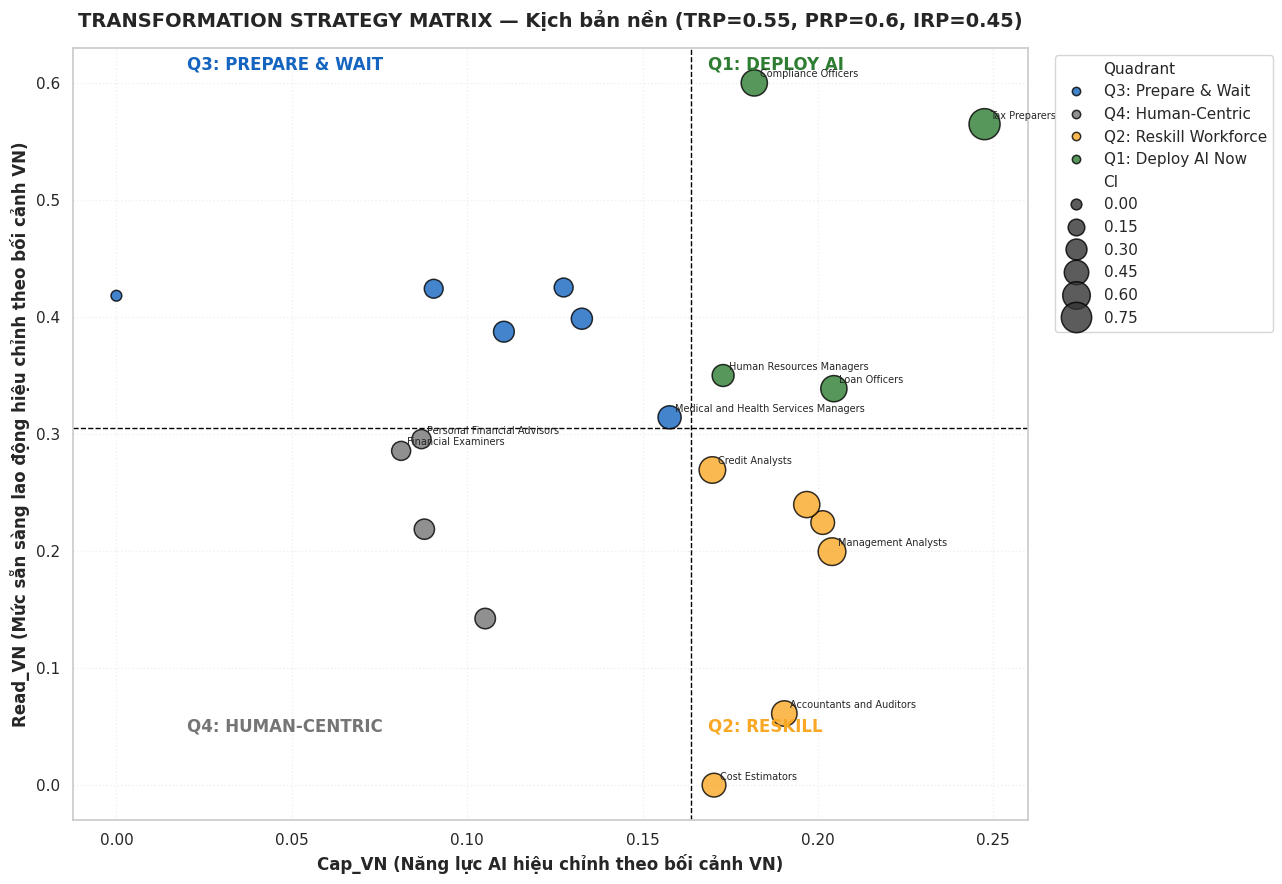

Số lượng nghề theo từng Quadrant:


,count
Quadrant,
Q4: Human-Centric,18
Q3: Prepare & Wait,6
Q2: Reskill Workforce,6
Q1: Deploy AI Now,4


In [ ]:
# ==========================================================
# TRANSFORMATION STRATEGY MATRIX — 4 QUADRANTS
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

def classify_quadrant(row, capT, readT):
    if row["Cap_VN"] >= capT and row["Read_VN"] >= readT:
        return "Q1: Deploy AI Now"
    elif row["Cap_VN"] >= capT and row["Read_VN"] < readT:
        return "Q2: Reskill Workforce"
    elif row["Cap_VN"] < capT and row["Read_VN"] >= readT:
        return "Q3: Prepare & Wait"      # Người sẵn sàng nhưng AI chưa đủ năng lực
    else:
        return "Q4: Human-Centric"        # Cả hai đều thấp

occ_master["Quadrant"] = occ_master.apply(
    lambda r: classify_quadrant(r, cap_thr, read_thr), axis=1
)

def plot_transformation_matrix(df, capT, readT, title="TRANSFORMATION STRATEGY MATRIX"):
    plt.figure(figsize=(13, 9))

    quadrant_colors = {
        "Q1: Deploy AI Now": "#2e7d32",
        "Q2: Reskill Workforce": "#f9a825",
        "Q3: Prepare & Wait": "#1565c0",
        "Q4: Human-Centric": "#757575",
    }

    ax = sns.scatterplot(
        data=df, x="Cap_VN", y="Read_VN",
        hue="Quadrant", palette=quadrant_colors,
        size="CI", sizes=(60, 500),
        alpha=0.8, edgecolor="black"
    )

    plt.axvline(capT, color="black", linestyle="--", linewidth=1)
    plt.axhline(readT, color="black", linestyle="--", linewidth=1)

    xmax, ymax = df["Cap_VN"].max() * 1.05, df["Read_VN"].max() * 1.05
    plt.text(capT + (xmax-capT)*0.05, ymax*0.97, "Q1: DEPLOY AI", fontweight="bold", color="#2e7d32")
    plt.text(capT + (xmax-capT)*0.05, readT*0.15, "Q2: RESKILL", fontweight="bold", color="#f9a825")
    plt.text(0.02, ymax*0.97, "Q3: PREPARE & WAIT", fontweight="bold", color="#1565c0")
    plt.text(0.02, readT*0.15, "Q4: HUMAN-CENTRIC", fontweight="bold", color="#757575")

    for _, row in df.iterrows():
        if row["CI"] >= ci_thr or abs(row["Cap_VN"]-capT) < 0.03 or abs(row["Read_VN"]-readT) < 0.03:
            plt.annotate(row["Occupation (O*NET-SOC Title)"],
                         (row["Cap_VN"], row["Read_VN"]),
                         fontsize=7, xytext=(4,4), textcoords="offset points")

    plt.title(title, fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Cap_VN (Năng lực AI hiệu chỉnh theo bối cảnh VN)", fontweight="bold")
    plt.ylabel("Read_VN (Mức sẵn sàng lao động hiệu chỉnh theo bối cảnh VN)", fontweight="bold")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

plot_transformation_matrix(occ_master, cap_thr, read_thr,
    title=f"TRANSFORMATION STRATEGY MATRIX — Kịch bản nền (TRP={TRP_BASE}, PRP={PRP_BASE}, IRP={IRP_BASE})")

print("Số lượng nghề theo từng Quadrant:")
display(occ_master["Quadrant"].value_counts())

## Vietnam Scenario Simulation — Điều chỉnh TRP / PRP / IRP bằng Slider
So sánh Before vs After để trả lời RQ5: nếu mức độ sẵn sàng của Việt Nam thay đổi thì
chiến lược chuyển đổi (vị trí các nghề trên ma trận) sẽ dịch chuyển như thế nào?

In [ ]:
# ==========================================================
# INTERACTIVE SCENARIO SIMULATION (ipywidgets sliders)
# Dùng chung hàm compute_vn_metrics() đã định nghĩa ở trên (công thức nhân, thống nhất)
# ==========================================================

trp_slider = widgets.FloatSlider(value=TRP_BASE, min=0.0, max=1.0, step=0.05,
                                  description="TRP:", continuous_update=False)
prp_slider = widgets.FloatSlider(value=PRP_BASE, min=0.0, max=1.0, step=0.05,
                                  description="PRP:", continuous_update=False)
irp_slider = widgets.FloatSlider(value=IRP_BASE, min=0.0, max=1.0, step=0.05,
                                  description="IRP:", continuous_update=False)

def run_simulation(TRP, PRP, IRP):
    # --- BEFORE: kịch bản nền ---
    before = compute_vn_metrics(occ_master.copy(), TRP_BASE, PRP_BASE, IRP_BASE)
    before, capT_b, readT_b, ciT_b = generate_recommendation(before.copy())

    before_filtered_wfi = before.dropna(subset=["WFI_VN", "Occupation (O*NET-SOC Title)"])
    top_wfi_occupations_df = before_filtered_wfi.sort_values(by="WFI_VN", ascending=False).head(5)[["Occupation (O*NET-SOC Title)"]]
    bottom_wfi_occupations_df = before_filtered_wfi.sort_values(by="WFI_VN", ascending=True).head(5)[["Occupation (O*NET-SOC Title)"]]
    key_occupations_for_comparison = pd.concat([top_wfi_occupations_df, bottom_wfi_occupations_df]).drop_duplicates().reset_index(drop=True)

    # --- AFTER: kịch bản theo giá trị slider ---
    after = compute_vn_metrics(occ_master.copy(), TRP, PRP, IRP)
    after, capT_a, readT_a, ciT_a = generate_recommendation(after.copy())
    after["Quadrant"] = after.apply(lambda r: classify_quadrant(r, capT_a, readT_a), axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    quadrant_colors = {
        "Q1: Deploy AI Now": "#2e7d32", "Q2: Reskill Workforce": "#f9a825",
        "Q3: Prepare & Wait": "#1565c0", "Q4: Human-Centric": "#757575",
    }

    before_plot_data = before.assign(Quadrant=before.apply(lambda r: classify_quadrant(r, capT_b, readT_b), axis=1))

    for ax, data, capT, readT, subtitle in [
        (axes[0], before_plot_data, capT_b, readT_b, f"BEFORE — TRP={TRP_BASE}, PRP={PRP_BASE}, IRP={IRP_BASE}"),
        (axes[1], after, capT_a, readT_a, f"AFTER — TRP={TRP}, PRP={PRP}, IRP={IRP}")
    ]:
        sns.scatterplot(data=data, x="Cap_VN", y="Read_VN", hue="Quadrant",
                         palette=quadrant_colors, size="CI", sizes=(50, 400),
                         alpha=0.8, edgecolor="black", ax=ax, legend=(ax==axes[1]))
        ax.axvline(capT, color="black", linestyle="--", linewidth=1)
        ax.axhline(readT, color="black", linestyle="--", linewidth=1)
        ax.set_title(subtitle, fontweight="bold")
        ax.set_xlabel("Cap_VN"); ax.set_ylabel("Read_VN")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(alpha=0.3, linestyle=":")

    if axes[1].get_legend() is not None:
        axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.suptitle("SO SÁNH DỊCH CHUYỂN CHIẾN LƯỢC THEO KỊCH BẢN PHÁT TRIỂN VIỆT NAM",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    comp = pd.DataFrame({
        "Before": before_plot_data["Quadrant"].value_counts(),
        "After": after["Quadrant"].value_counts()
    }).fillna(0).astype(int)
    print("Bảng so sánh số lượng nghề theo từng vùng chiến lược:")
    display(comp)

    wfi_comparison = key_occupations_for_comparison.merge(
        before[["Occupation (O*NET-SOC Title)", "WFI_VN"]].rename(columns={"WFI_VN": "WFI_VN (Baseline)"}),
        on="Occupation (O*NET-SOC Title)",
        how="left"
    ).merge(
        after[["Occupation (O*NET-SOC Title)", "WFI_VN"]].rename(columns={"WFI_VN": "WFI_VN (Simulated)"}),
        on="Occupation (O*NET-SOC Title)",
        how="left"
    )
    wfi_comparison = wfi_comparison[["Occupation (O*NET-SOC Title)", "WFI_VN (Baseline)", "WFI_VN (Simulated)"]].sort_values(by="WFI_VN (Baseline)", ascending=False).reset_index(drop=True)

    print("\nSo sánh WFI_VN cho các nghề nghiệp tiêu biểu:")
    display(wfi_comparison)

out = interactive_output(run_simulation, {"TRP": trp_slider, "PRP": prp_slider, "IRP": irp_slider})
display(VBox([HBox([trp_slider, prp_slider, irp_slider]), out]))


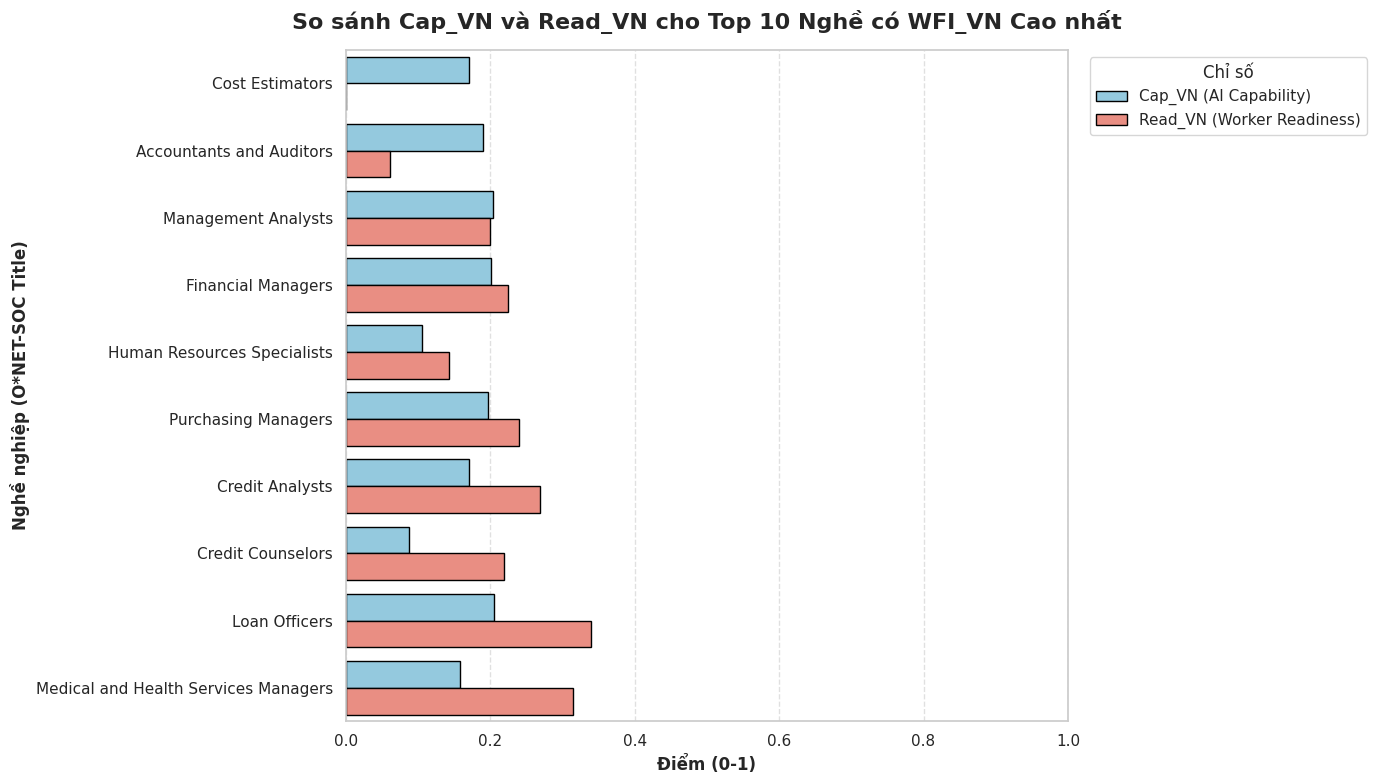

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 occupations by WFI_VN (Worker Friction Index in Vietnam scenario)
# Filter out any NaNs in WFI_VN before sorting to ensure valid comparison
top_10_wfi_vn = occ_master.dropna(subset=["WFI_VN"]).sort_values(by="WFI_VN", ascending=False).head(10).copy()

# Reshape the DataFrame for plotting: melt Cap_VN and Read_VN into a single column
plot_data = top_10_wfi_vn.melt(
    id_vars=["Occupation (O*NET-SOC Title)"],
    value_vars=["Cap_VN", "Read_VN"],
    var_name="Metric",
    value_name="Score"
)

# Map metric names for better readability on the plot
metric_labels = {"Cap_VN": "Cap_VN (AI Capability)", "Read_VN": "Read_VN (Worker Readiness)"}
plot_data["Metric"] = plot_data["Metric"].map(metric_labels)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=plot_data,
    x="Score",
    y="Occupation (O*NET-SOC Title)",
    hue="Metric",
    palette={"Cap_VN (AI Capability)": "skyblue", "Read_VN (Worker Readiness)": "salmon"},
    edgecolor="black"
)

plt.title("So sánh Cap_VN và Read_VN cho Top 10 Nghề có WFI_VN Cao nhất", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Điểm (0-1)", fontsize=12, fontweight="bold")
plt.ylabel("Nghề nghiệp (O*NET-SOC Title)", fontsize=12, fontweight="bold")
plt.legend(title="Chỉ số", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlim(0, 1) # Cap_VN and Read_VN are normalized between 0 and 1
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Tính EconomicExposure
# Điền 0 vào các giá trị NaN cho WEI, PEI, CI khi tính EconomicExposure
# Điều này ngụ ý rằng nếu một chỉ số không có giá trị, nó không đóng góp vào exposure.
occ_master['EconomicExposure'] = (
    occ_master['WEI'].fillna(0) + occ_master['PEI'].fillna(0) + occ_master['CI'].fillna(0)
) / 3

# Tính AIPS = Cap_norm * Read_norm * EconomicExposure
# Nếu Cap_norm hoặc Read_norm là NaN, AIPS cũng sẽ là NaN.
occ_master['AIPS'] = occ_master['Cap_norm'] * occ_master['Read_norm'] * occ_master['EconomicExposure']

print("Các nghề có AI Prioritization Score (AIPS) cao nhất:")
display(occ_master[['Occupation (O*NET-SOC Title)', 'Cap_norm', 'Read_norm', 'WEI', 'PEI', 'CI', 'EconomicExposure', 'AIPS']].sort_values(by='AIPS', ascending=False).head(10))

print("\nCác nghề có AI Prioritization Score (AIPS) thấp nhất:")
display(occ_master[['Occupation (O*NET-SOC Title)', 'Cap_norm', 'Read_norm', 'WEI', 'PEI', 'CI', 'EconomicExposure', 'AIPS']].sort_values(by='AIPS', ascending=True).head(10))

Các nghề có AI Prioritization Score (AIPS) cao nhất:


,Occupation (O*NET-SOC Title),Cap_norm,Read_norm,WEI,PEI,CI,EconomicExposure,AIPS
33,Tax Preparers,1.000000,0.941308,0.045665,0.022483,0.789862,0.286003,0.269217
15,Compliance Officers,0.734767,1.000000,0.198920,0.161804,0.532734,0.297820,0.218828
4,Financial Managers,0.813579,0.373935,0.457948,0.767265,0.413663,0.546292,0.166196
31,Loan Officers,0.826458,0.564611,0.162216,0.188502,0.531294,0.294004,0.137190
7,Human Resources Managers,0.698864,0.583370,0.100781,0.553325,0.339770,0.331292,0.135066
19,Management Analysts,0.824303,0.332508,0.507062,0.367037,0.603033,0.492377,0.134955
5,Purchasing Managers,0.795191,0.399548,0.040546,0.570298,0.529975,0.380273,0.120819
11,Medical and Health Services Managers,0.637201,0.523769,0.246852,0.394766,0.390053,0.343890,0.114772
26,Credit Analysts,0.686487,0.448820,0.028394,0.219042,0.547744,0.265060,0.081667
0,Advertising and Promotions Managers,0.515170,0.708678,0.004760,0.364168,0.224744,0.197891,0.072248



Các nghề có AI Prioritization Score (AIPS) thấp nhất:


,Occupation (O*NET-SOC Title),Cap_norm,Read_norm,WEI,PEI,CI,EconomicExposure,AIPS
3,Computer and Information Systems Managers,0.000000,0.696941,0.000000,0.000000,0.000000,0.000000,0.000000
16,Cost Estimators,0.688381,0.000000,0.101185,0.142106,0.416359,0.219883,0.000000
30,Credit Counselors,0.354717,0.364492,0.005004,0.000000,0.274716,0.093240,0.012055
29,Financial Examiners,0.327975,0.476021,0.012532,0.118578,0.229129,0.120079,0.018747
17,Human Resources Specialists,0.424824,0.237247,0.268275,0.076668,0.283335,0.209426,0.021108
22,Training and Development Specialists,0.365507,0.706929,0.108807,0.049444,0.222336,0.126863,0.032780
27,Personal Financial Advisors,0.351414,0.492806,0.064084,0.277513,0.234492,0.192030,0.033255
24,Accountants and Auditors,0.769367,0.102009,0.769367,0.219162,0.494846,0.494458,0.038806
25,Budget Analysts,0.446337,0.645728,0.012202,0.128495,0.295159,0.145285,0.041873
20,Fundraisers,0.536155,0.664223,0.036528,0.069972,0.305880,0.137460,0.048953


In [ ]:
print("\n--- Phân loại Ưu tiên Đầu tư AI dựa trên AIPS ---")
# Xác định ngưỡng cho các loại AIPS (Low, Medium, High) sử dụng phân vị
# Loại bỏ NaN khỏi AIPS trước khi tính toán phân vị để tránh lỗi và đảm bảo tính toán chính xác
valid_aips = occ_master['AIPS'].dropna()

if not valid_aips.empty:
    low_threshold = valid_aips.quantile(0.33)  # Dưới 33% là Low
    high_threshold = valid_aips.quantile(0.67) # Trên 67% là High

    def categorize_aips(aips_score):
        if pd.isna(aips_score):
            return "Không xác định"
        elif aips_score <= low_threshold:
            return "AIPS Thấp (Chưa nên ưu tiên)"
        elif aips_score > high_threshold:
            return "AIPS Cao (Ưu tiên triển khai AI)"
        else:
            return "AIPS Trung bình (Thử nghiệm từng phần)"

    occ_master['AIPS_Category'] = occ_master['AIPS'].apply(categorize_aips)

    print("Ngưỡng phân loại AIPS:")
    print(f"  - Thấp: <= {low_threshold:.4f}")
    print(f"  - Cao: > {high_threshold:.4f}\n")

    print("Phân bố các nghề nghiệp theo Nhóm ưu tiên đầu tư AI:")
    display(occ_master['AIPS_Category'].value_counts())

    print("\nMột số nghề nghiệp với phân loại AIPS:")
    display(occ_master[['Occupation (O*NET-SOC Title)', 'AIPS', 'AIPS_Category']].sort_values(by='AIPS').head(5))
    display(occ_master[['Occupation (O*NET-SOC Title)', 'AIPS', 'AIPS_Category']].sort_values(by='AIPS', ascending=False).head(5))
else:
    print("Không thể tính toán AIPS Categories vì cột 'AIPS' chứa toàn bộ NaN hoặc rỗng.")



--- Phân loại Ưu tiên Đầu tư AI dựa trên AIPS ---
Ngưỡng phân loại AIPS:
  - Thấp: <= 0.0348
  - Cao: > 0.1192

Phân bố các nghề nghiệp theo Nhóm ưu tiên đầu tư AI:


,count
AIPS_Category,
Không xác định,14
AIPS Thấp (Chưa nên ưu tiên),7
AIPS Cao (Ưu tiên triển khai AI),7
AIPS Trung bình (Thử nghiệm từng phần),6



Một số nghề nghiệp với phân loại AIPS:


,Occupation (O*NET-SOC Title),AIPS,AIPS_Category
3,Computer and Information Systems Managers,0.000000,AIPS Thấp (Chưa nên ưu tiên)
16,Cost Estimators,0.000000,AIPS Thấp (Chưa nên ưu tiên)
30,Credit Counselors,0.012055,AIPS Thấp (Chưa nên ưu tiên)
29,Financial Examiners,0.018747,AIPS Thấp (Chưa nên ưu tiên)
17,Human Resources Specialists,0.021108,AIPS Thấp (Chưa nên ưu tiên)


,Occupation (O*NET-SOC Title),AIPS,AIPS_Category
33,Tax Preparers,0.269217,AIPS Cao (Ưu tiên triển khai AI)
15,Compliance Officers,0.218828,AIPS Cao (Ưu tiên triển khai AI)
4,Financial Managers,0.166196,AIPS Cao (Ưu tiên triển khai AI)
31,Loan Officers,0.137190,AIPS Cao (Ưu tiên triển khai AI)
7,Human Resources Managers,0.135066,AIPS Cao (Ưu tiên triển khai AI)


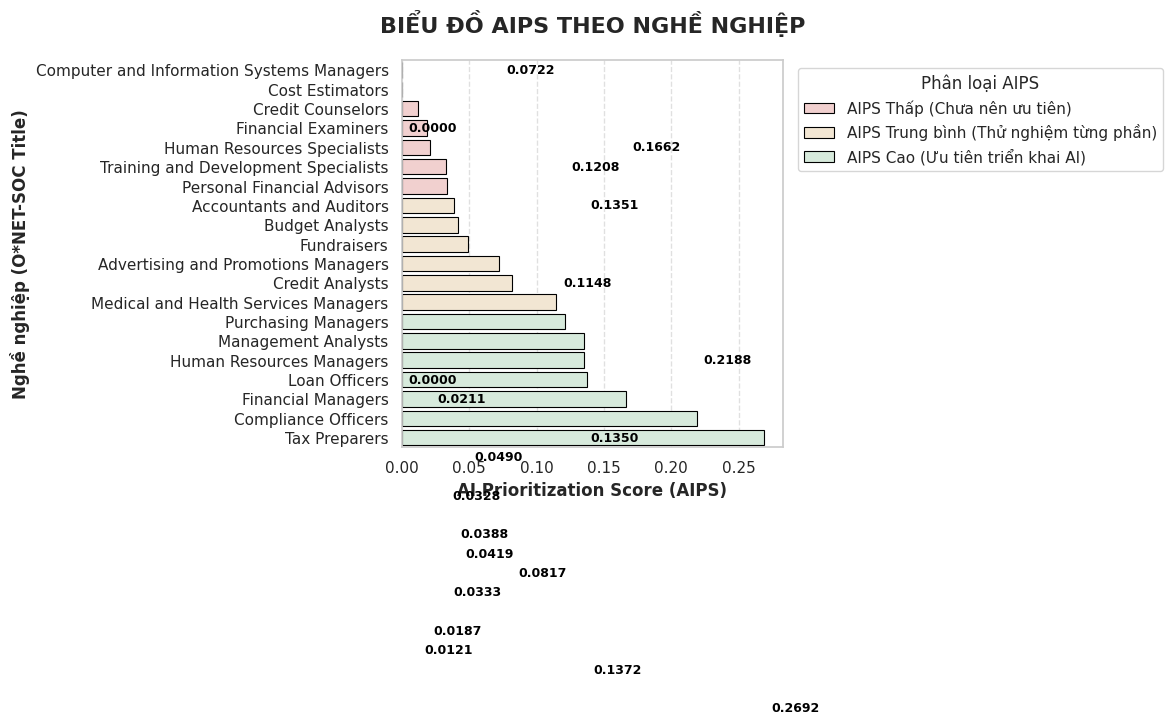

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Filter out NaN values from AIPS for plotting
plot_data_aips = occ_master.dropna(subset=['AIPS', 'AIPS_Category']).sort_values(by='AIPS', ascending=True).copy()

# Define colors for AIPS categories
aips_palette = {
    "AIPS Thấp (Chưa nên ưu tiên)": "#F7CAC9",
    "AIPS Trung bình (Thử nghiệm từng phần)": "#F7E7CE",
    "AIPS Cao (Ưu tiên triển khai AI)": "#D4EDDA",
    "Không xác định": "#CCCCCC" # Grey for undefined, though should be filtered out by dropna
}

# Create the bar plot
sns.barplot(
    data=plot_data_aips,
    x='AIPS',
    y='Occupation (O*NET-SOC Title)',
    hue='AIPS_Category', # Color bars by the AIPS category
    palette=aips_palette,
    dodge=False, # Ensure bars are not dodged if multiple categories per occupation exist (they shouldn't)
    edgecolor='black',
    linewidth=0.8
)

# Add AIPS values on the bars
for index, row in plot_data_aips.iterrows():
    plt.text(
        row['AIPS'] + 0.005, # Position text slightly to the right of the bar
        row.name, # Y-position corresponds to the row index in the plot_data_aips
        f"{row['AIPS']:.4f}",
        color='black',
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('BIỂU ĐỒ AIPS THEO NGHỀ NGHIỆP', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('AI Prioritization Score (AIPS)', fontsize=12, fontweight='bold')
plt.ylabel('Nghề nghiệp (O*NET-SOC Title)', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Phân loại AIPS', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# 1. Tính toán chỉ số WTRS (Workforce Transformation Risk Score)
# WTRS = Cap_norm * (1 - Read_norm) * EconomicExposure
occ_master['WTRS'] = occ_master['Cap_norm'] * (1 - occ_master['Read_norm']) * occ_master['EconomicExposure']

print("Các nghề có WTRS cao nhất (Rủi ro chuyển đổi lực lượng lao động cao):")
display(occ_master[['Occupation (O*NET-SOC Title)', 'Cap_norm', 'Read_norm', 'EconomicExposure', 'WTRS']].sort_values(by='WTRS', ascending=False).head())

print("\nCác nghề có WTRS thấp nhất (Rủi ro chuyển đổi lực lượng lao động thấp):")
display(occ_master[['Occupation (O*NET-SOC Title)', 'Cap_norm', 'Read_norm', 'EconomicExposure', 'WTRS']].sort_values(by='WTRS', ascending=True).head())

# 2. Định nghĩa các ngưỡng cho Decision Engine
# Sử dụng median cho 'trung bình', upper/lower quantiles cho 'cao/thấp'

# Cap_norm và Read_norm đều nằm trong khoảng [0, 1]
cap_high_threshold = occ_master['Cap_norm'].median() # Để đơn giản, 'cao' là trên median
cap_low_threshold = occ_master['Cap_norm'].median() # 'thấp' là dưới median
cap_medium_lower = occ_master['Cap_norm'].quantile(0.25)
cap_medium_upper = occ_master['Cap_norm'].quantile(0.75)

read_high_threshold = occ_master['Read_norm'].median()
read_low_threshold = occ_master['Read_norm'].median()

exposure_high_threshold = occ_master['EconomicExposure'].median() # 'cao' là trên median

ci_high_threshold = occ_master['CI'].quantile(0.75) # Top 25% rủi ro cao nhất

wtrs_low_threshold = occ_master['WTRS'].quantile(0.25) # Bottom 25% rủi ro thấp nhất
wtrs_high_threshold = occ_master['WTRS'].quantile(0.75) # Top 25% rủi ro cao nhất

def apply_decision_rules(row):
    cap_val = row['Cap_norm']
    read_val = row['Read_norm']
    exposure_val = row['EconomicExposure']
    ci_val = row['CI']
    wtrs_val = row['WTRS']

    # Handle NaN values for critical metrics, assigning a default strategy
    if pd.isna(cap_val) or pd.isna(read_val) or pd.isna(exposure_val) or pd.isna(ci_val) or pd.isna(wtrs_val):
        return "Strategy Undefined (Missing Data)"

    # Rule 1: Deploy AI
    # (Điều kiện: Cap cao, Read cao, Exposure cao, WTRS thấp)
    if (cap_val >= cap_high_threshold and
        read_val >= read_high_threshold and
        exposure_val >= exposure_high_threshold and
        wtrs_val <= wtrs_low_threshold):
        return "Deploy AI"

    # Rule 2: Reskill Workforce
    # (Điều kiện: Cap cao, Read thấp, WTRS cao)
    elif (cap_val >= cap_high_threshold and
          read_val < read_low_threshold and
          wtrs_val >= wtrs_high_threshold):
        return "Reskill Workforce"

    # Rule 3: Human-AI Collaboration
    # (Điều kiện: Cap trung bình, CI cao)
    elif (cap_val >= cap_medium_lower and cap_val < cap_medium_upper and
          ci_val >= ci_high_threshold):
        return "Human-AI Collaboration"

    # Rule 4: Human-led
    # (Điều kiện: Cap thấp, CI cao)
    elif (cap_val < cap_low_threshold and
          ci_val >= ci_high_threshold):
        return "Human-led"

    # Default or other cases
    return "Review Manually"

# Drop rows with NaN values in the critical columns before applying decision rules
# This addresses the user's request to 'resolve' NaN values by excluding them from this specific analysis step.
occ_master_cleaned = occ_master.dropna(subset=['Cap_norm', 'Read_norm', 'EconomicExposure', 'CI', 'WTRS']).copy()

occ_master_cleaned['Transformation_Strategy'] = occ_master_cleaned.apply(apply_decision_rules, axis=1)

# Temporarily set display options to ensure full output
original_max_rows = pd.get_option('display.max_rows')
original_max_columns = pd.get_option('display.max_columns')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("\nPhân bố các nghề nghiệp theo Chiến lược Chuyển đổi:")
display(occ_master_cleaned['Transformation_Strategy'].value_counts())

print("\nCác nghề nghiệp với Chiến lược Chuyển đổi:")
display(occ_master_cleaned[['Occupation (O*NET-SOC Title)', 'Cap_norm', 'Read_norm', 'EconomicExposure', 'WTRS', 'CI', 'Transformation_Strategy']].head(10))

# Reset display options to original values
pd.set_option('display.max_rows', original_max_rows)
pd.set_option('display.max_columns', original_max_columns)


Các nghề có WTRS cao nhất (Rủi ro chuyển đổi lực lượng lao động cao):


,Occupation (O*NET-SOC Title),Cap_norm,Read_norm,EconomicExposure,WTRS
24,Accountants and Auditors,0.769367,0.102009,0.494458,0.341613
4,Financial Managers,0.813579,0.373935,0.546292,0.278256
19,Management Analysts,0.824303,0.332508,0.492377,0.270914
5,Purchasing Managers,0.795191,0.399548,0.380273,0.181570
16,Cost Estimators,0.688381,0.000000,0.219883,0.151363



Các nghề có WTRS thấp nhất (Rủi ro chuyển đổi lực lượng lao động thấp):


,Occupation (O*NET-SOC Title),Cap_norm,Read_norm,EconomicExposure,WTRS
3,Computer and Information Systems Managers,0.000000,0.696941,0.000000,0.000000
15,Compliance Officers,0.734767,1.000000,0.297820,0.000000
22,Training and Development Specialists,0.365507,0.706929,0.126863,0.013589
33,Tax Preparers,1.000000,0.941308,0.286003,0.016786
29,Financial Examiners,0.327975,0.476021,0.120079,0.020636



Phân bố các nghề nghiệp theo Chiến lược Chuyển đổi:


,count
Transformation_Strategy,
Review Manually,12
Reskill Workforce,5
Deploy AI,2
Human-AI Collaboration,1



Các nghề nghiệp với Chiến lược Chuyển đổi:


,Occupation (O*NET-SOC Title),Cap_norm,Read_norm,EconomicExposure,WTRS,CI,Transformation_Strategy
0,Advertising and Promotions Managers,0.515170,0.708678,0.197891,0.029699,0.224744,Review Manually
3,Computer and Information Systems Managers,0.000000,0.696941,0.000000,0.000000,0.000000,Review Manually
4,Financial Managers,0.813579,0.373935,0.546292,0.278256,0.413663,Reskill Workforce
5,Purchasing Managers,0.795191,0.399548,0.380273,0.181570,0.529975,Reskill Workforce
7,Human Resources Managers,0.698864,0.583370,0.331292,0.096462,0.339770,Review Manually
11,Medical and Health Services Managers,0.637201,0.523769,0.343890,0.104355,0.390053,Review Manually
15,Compliance Officers,0.734767,1.000000,0.297820,0.000000,0.532734,Deploy AI
16,Cost Estimators,0.688381,0.000000,0.219883,0.151363,0.416359,Reskill Workforce
17,Human Resources Specialists,0.424824,0.237247,0.209426,0.067861,0.283335,Review Manually
19,Management Analysts,0.824303,0.332508,0.492377,0.270914,0.603033,Reskill Workforce


In [ ]:
occ_master_cleaned.to_csv('occ_master_cleaned.csv', index=False)
print("DataFrame 'occ_master_cleaned' đã được xuất ra file 'occ_master_cleaned.csv'.")

DataFrame 'occ_master_cleaned' đã được xuất ra file 'occ_master_cleaned.csv'.
